# Gravitational Sonar
### Abstract: We present an algorithm -- which, if successful -- would be capable of predicting an approximate spacetime metric for a binary black hole system to within $<1\%$ error of the innermost-stable circular orbit (ISCO). Our algorithm, coined Gravitational Sonar, is valid in the Extreme-Mass Ratio Inspiral (EMRI) limit wherein $m_1>>m_2$. We will validate our algorithm for the Schwarzschild, Kerr, and Johannsen Metrics. We will demonstrate that the algorithm can be employed on LISA waveforms with noise $\sigma>0.05$ to test the No-Hair Theorem and probe for beyond-GR corrections.

# Library Installations

In [ ]:
pip install pytearcat

In [ ]:
pip install torch

In [ ]:
pip install torchdiffeq

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from torchdiffeq import odeint

In [ ]:
import pytearcat as pt

In [ ]:
!wget -q https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py

In [ ]:
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [ ]:
pip install torch torchdiffeq

In [ ]:
pip install xitorch

In [ ]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
from scipy.optimize import minimize as minimize_ssbroyden

In [ ]:
!grep -n "^def _minimize_bfgs" _optimize.py

1415:def _minimize_bfgs(fun, x0, args=(), jac=None, callback=None,


In [ ]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize  # vanilla dispatcher — now calls the patched BFGS internals

# Import Gravitational Waveforms

We import gravitational waves which were created using a Numerical Kludge orbit-to-waveform mapping forward algorithm (i.e., Quadrupole Approximation + Kerr Geodesics). For a test case, we import just one gravitational wave (technically, there are two polarizations $h_+$ and $h_\times$, so there's two).

Things to test:
- Upgrade from 1 to 3 sets of waveforms, generated by observing the same geodesic from three perspectives (testing the idea of "GPS for Black Holes")
- Since $h_\times \to 0$ as $\theta \to \pi/2$, it may be interesting to try weighting edge-on observers differently than face-on observers to see if it increases the "signal" for numerically smaller components of the Kerr metric
- Not all metric components are created equal: They may not contribute equally to the waveform, so it's important to know which ones contribute the most or least. (Perhaps this would be a so-called "Fisher Analysis" to identify potential sloppy valleys)

θ_obs: 0
|h1|_min: tensor(0.0399)
|h1|_max: tensor(0.3530)


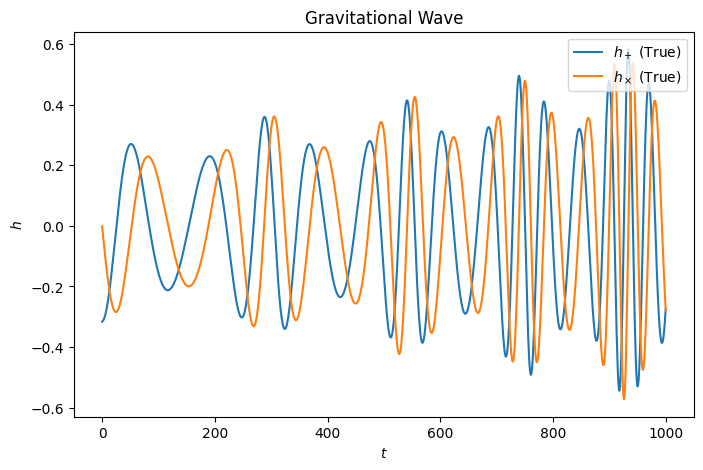

θ_obs: pi/4
|h2|_min: tensor(2.4473e-05)
|h2|_max: tensor(0.6018)


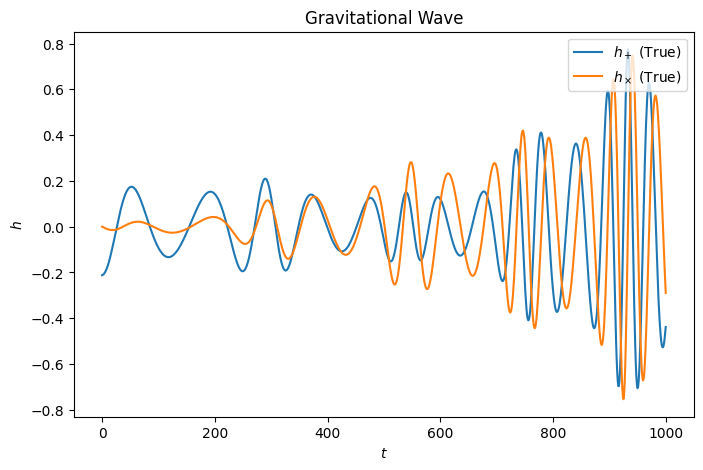

In [ ]:
t_true, h_plus_true_obs1 = np.loadtxt('/content/waveform_real_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.txt', unpack = True)
t_true, h_cross_true_obs1 = np.loadtxt('/content/waveform_imag_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.txt', unpack = True)

h_plus_true_obs1 = torch.tensor(h_plus_true_obs1, dtype = torch.float32)
h_cross_true_obs1 = torch.tensor(h_cross_true_obs1, dtype = torch.float32)

print("θ_obs: 0")
print("|h1|_min:", min(h_plus_true_obs1**2 + h_cross_true_obs1**2))
print("|h1|_max:", max(h_plus_true_obs1**2 + h_cross_true_obs1**2))

fig, ax = plt.subplots(figsize=(8,5))
plt.plot(t_true, h_plus_true_obs1, label = r"$h_+$ (True)")
plt.plot(t_true, h_cross_true_obs1, label = r"$h_\times$ (True)")
plt.legend(loc = "upper right")
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.title('Gravitational Wave')
plt.show()

t_true, h_plus_true_obs2 = np.loadtxt('/content/waveform_real_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.7853981633974483.txt', unpack = True)
t_true, h_cross_true_obs2 = np.loadtxt('/content/waveform_imag_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.7853981633974483.txt', unpack = True)

h_plus_true_obs2 = torch.tensor(h_plus_true_obs2, dtype = torch.float32)
h_cross_true_obs2 = torch.tensor(h_cross_true_obs2, dtype = torch.float32)

print("θ_obs: pi/4")
print("|h2|_min:", min(h_plus_true_obs2**2 + h_cross_true_obs2**2))
print("|h2|_max:", max(h_plus_true_obs2**2 + h_cross_true_obs2**2))

fig2, ax2 = plt.subplots(figsize=(8,5))
plt.plot(t_true, h_plus_true_obs2, label = r"$h_+$ (True)")
plt.plot(t_true, h_cross_true_obs2, label = r"$h_\times$ (True)")
plt.legend(loc = "upper right")
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.title('Gravitational Wave')
plt.show()

# Input Parameters

The neural network is supplied with the exact orbital parameters (and thus, supplied with the correct initial conditions).

Things to test:
- Approach 1: A curriculum-based approach where one chops up the waveform into many pieces and iteratively trains on larger sections of the waveform (i.e., increase `t_test` from `[:600]` to `[:1200]` to `[:2000]`)
- Approach 2: Train on the entire waveform from the start, but iteratively sample the waveform with more points (i.e., increase `t_test` from `[::40]` to `[::100]` to `[::500]`)

In [ ]:
rp_true = 10
ra_true = 14
a_true = 0.9
θmin_true = math.pi/4
θ_observed = [0, math.pi/4]

In [ ]:
t = torch.linspace(0, 1000, 1000)
t_final = 1000
t_test = t[:t_final]

print(len(t))
print(len(t_test))

1000
1000


In [ ]:
h_plus_true = [h_plus_true_obs1[:t_final],
               h_plus_true_obs2[:t_final]]
h_cross_true = [h_cross_true_obs1[:t_final],
                h_cross_true_obs2[:t_final]]

# Neural Network

Build the neural network to be extremely small and simple (for starters).

Things to test:
- Increase neural network dimensions (although historically, this should be a last resort)
- Try different network architechtures (i.e., hourglass)
- Try different activation functions (i.e., ReLU, SiLU, etc.)
- Try different neural network inputs (i.e., [log(r), Θ] instead of [r, Θ])

In [ ]:
import torch

class NN_Metric(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(2, 8) # 2 inputs -> 8 hidden features
    self.act = torch.nn.SiLU()       # non-linear hidden transform
    self.fc2 = torch.nn.Linear(8, 5) # 8 hidden features -> 5 metric fields

  def forward(self, x):
    hidden = self.act(self.fc1(x))
    return self.fc2(hidden)

In [ ]:
def nn_input(r, θ):
  return torch.stack([
      1/r,
      torch.cos(θ).square()
  ])

In [ ]:
torch.manual_seed(0)
net = NN_Metric()
x = torch.tensor([2.0, 1.57])
out = net(x)
print(out)

tensor([-0.0663, -0.2923, -0.1640,  0.0423,  0.4105], grad_fn=<ViewBackward0>)


In [ ]:
def Kerr(x, a, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  Δ = r**2 - 2*M*r + a**2
  Σ = r**2 + a**2 * (torch.cos(θ))**2
  A = (r**2 + a**2)**2 - Δ * a**2 * (torch.sin(θ))**2
  g_tt = -(1-2*M*r/Σ)
  g_rr = Σ/Δ
  g_θθ = Σ
  g_ϕϕ = A/Σ * (torch.sin(θ))**2
  g_tϕ = (-2*M*r/Σ) * a * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, g_tϕ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tϕ, zero, zero, g_ϕϕ])
  kerr = torch.stack([row1, row2, row3, row4])
  return kerr

def g_Kerr(r, θ, M=1.0, a=a_true):

  Σ = lambda r, θ: r**2 + (a**2)*(torch.cos(θ))**2
  Δ = lambda r, θ: r**2 - 2*M*r + a**2
  A = (r**2 + a**2)**2 - Δ(r, θ) * a**2 * (torch.sin(θ))**2

  g_tt = - (1 - 2*M*r / Σ(r, θ))
  g_rr = Σ(r, θ) / Δ(r, θ)
  g_θθ = Σ(r, θ)
  g_φφ = A / Σ(r, θ) * (torch.sin(θ))**2
  g_tφ = - (2*M*r / Σ(r, θ)) * a * (torch.sin(θ))**2

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

# Ansatz

This ansatz was designed very carefully with a two-scale approach in mind:
- The ansatz must approach the correct far-field Minkowski flat spacetime limit as $r\to ∞$
- The ansatz should respect any poles or be able to represent any divergences or blow-ups in metric components as $r\to r_+$ (Outer Event Horizon of Kerr). Examples: $g_{tt}=0$ is the Ergosphere, $g^{rr}=0$ is the Event Horizon, $g_{\theta\theta}=0$ is the Singularity, and $-g_{t\phi}/g_{\phi\phi}=\omega$
- As $r\to r_+$ during the inspiral, frame-dragging should cause the second, smaller black hole to orbit the central black hole at $\Omega \to \Omega_H$, the horizon's own angular spin rate. This should be reflected in the gravitational wave frequency, which is twice that of the orbital frequency. Thus, the gravitational wave frequency at the peak amplitude should directly tell us the size of the event horizon for the massive, central black hole. I believe that this deduction holds only for EMRIs (Extreme-Mass Ratio Inspirals), where the smaller, secondary black hole can be treated as a particle on a geodesic around the larger black hole.
- The ansatz is inspired by a post-newtonian expansion, with the 0th-order $O(g^0)$ term being flat, Minkowski spacetime; the 1st-order term $O(g^1)$ is Schwarzschild spacetime; the 2nd-order term $O(g^2)$ is Kerr spacetime; the 3rd-order term $O(g^3)$ or beyond would be corrections to Kerr or beyond-GR, ideally, although the ansatz does not have this yet perhaps.
- Try using `ln(r)` as an input for the neural network?

In [ ]:
import torch.nn.functional as F

def NN_Ansatz(r, θ, NN):
  u = 1 / r

  g_tt = -1 + u * NN[0]
  g_rr_inv = 1 + u * NN[1]
  g_rr = 1 / g_rr_inv
  g_θθ = r**2 + NN[2]
  g_φφ = torch.sin(θ)**2 * (r**2 + NN[3])
  g_tφ = u * torch.sin(θ)**2 * NN[4]

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

In [ ]:
GTPHI_ALPHA = None

def metric_from_network(network, r, θ, params_dict=None):
  inputs = nn_input(r, θ)

  if params_dict is None:
    fields = network(inputs)
  else:
    fields = torch.func.functional_call(
        network, params_dict, (inputs,)
    )

  metric = NN_Ansatz(r, θ, fields)

  # Diagnostic only: continuously replace learned g_tφ with Kerr g_tφ.
  if GTPHI_ALPHA is None:
    return metric

  Σ = r**2 + a_true**2 * torch.cos(θ)**2
  kerr_gtφ = -2 * r * a_true * torch.sin(θ)**2 / Σ
  blended_gtφ = (1 - GTPHI_ALPHA) * metric[0, 3] + GTPHI_ALPHA * kerr_gtφ

  row1 = torch.stack([metric[0, 0], metric[0, 1], metric[0, 2], blended_gtφ])
  row4 = torch.stack([blended_gtφ, metric[3, 1], metric[3, 2], metric[3, 3]])
  return torch.stack([row1, metric[1], metric[2], row4])


# Hamiltonian

The Hamiltonian is constructed from a given metric as $H=\frac{1}{2}*p_\mu*g^{\mu\nu}*p_\nu$. I have now included a very simple dissipation term.

Things to test:
- For the initial test, dissipation will be baked in! The neural network will not be asked to predict it. Its only job will be to predict the kerr metric by making the right predictions for its 10 outputs.
- If the first preliminary test succeeds, where the network is able to predict the kerr metric (with dissipation baked in), then I will upgrade the dissipation term to be more realistic, reflecting post-newtonian $\dot \phi \propto r^{-7/2}$ dissipation
- If that test also succeeds, then I'll create a separate neural network `NN_Dissipative` which attempts to predict the dissipation whilst `NN_Conservative` predicts the entire kerr metric

In [ ]:
def H_function(state, network, params_dict):
  x = state

  def H(state):
    t, r, θ, φ, p_t, p_r, p_θ, p_φ = state
    g = metric_from_network(network, r, θ, params_dict)
    inv_g = torch.linalg.inv(g)

    p = torch.stack([p_t, p_r, p_θ, p_φ])
    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(x)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


# Quadrupole Approximation

In [ ]:
def d2_dt2(v, dt):
    # uses second-order one-sided difference stencils at the endpoints; see https://doi.org/10.1090/S0025-5718-1988-0935077-0
    a = 2*v[0] - 5*v[1] + 4*v[2] - v[3]
    b = v[:-2] - 2*v[1:-1] + v[2:]
    c = 2*v[-1] - 5*v[-2] + 4*v[-3] - v[-4]

    return torch.cat([a.reshape(1), b, c.reshape(1)])/(dt**2)

def Soln2Orbit(soln, t, a):
  r = soln[:, 1]
  θ = soln[:, 2]
  ϕ = soln[:, 3]

  x, y, z = BoyerLindquist2Cartesian(r, θ, ϕ, a = a)
  orbit = torch.stack([x, y, z])

  return orbit

def BoyerLindquist2Cartesian(r, θ, ϕ, a):

  x = r * torch.sin(θ) * torch.cos(ϕ)
  y = r * torch.sin(θ) * torch.sin(ϕ)
  z = r * torch.cos(θ)

  return x, y, z

def Q_ij(orbit, t, μ = 1.0):
  N = orbit.shape[1]
  Q = torch.zeros(3, 3, N)

  for i in range(3):
    for j in range(3):
      for k in range(N):
        δij = 1.0 if i==j else 0.0
        x = orbit[:, k]
        r2 = torch.sum(x**2)
        Q[i, j, k] = μ * (x[i] * x[j] - (1/3) * δij * r2)
  return Q

def Q_ddot(Q, dt):
  Qdd = torch.zeros_like(Q)

  for i in range(3):
    for j in range(3):
      Qdd[i, j, :] = d2_dt2(Q[i, j, :], dt)

  return Qdd

In [ ]:
def assert_uniform_time(t, rtol = 1e-3):
  dt = t[1] - t[0]
  assert torch.all(torch.abs(torch.diff(t) - dt) < rtol * torch.abs(dt)), "t must be uniformly sampled in coordinate time!"
  return dt

def Observer_Basis(θ_obs, ϕ_obs):
  n = [
      torch.sin(θ_obs) * torch.cos(ϕ_obs),
      torch.sin(θ_obs) * torch.sin(ϕ_obs),
      torch.cos(θ_obs)
  ]

  p = [
      torch.cos(θ_obs) * torch.cos(ϕ_obs),
      torch.cos(θ_obs) * torch.sin(ϕ_obs),
    - torch.sin(θ_obs)
  ]

  q = [
    - torch.sin(ϕ_obs),
      torch.cos(ϕ_obs),
      0.0
  ]

  return n, p, q

Observer_Basis(torch.tensor(0.0), torch.tensor(0.0))

def h(Qdd, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  n, p, q = Observer_Basis(torch.tensor(θ_obs), torch.tensor(ϕ_obs))
  N = Qdd.shape[2]

  h_plus = torch.zeros(N)
  h_cross = torch.zeros(N)

  for k in range(N):
    h_plus_k = 0
    h_cross_k = 0
    for i in range(3):
      for j in range(3):

        e_plus = p[i] * p[j] - q[i] * q[j]
        e_cross = p[i] * q[j] + q[i] * p[j]

        h_plus_k += (1/D) * e_plus * Qdd[i, j, k]
        h_cross_k += (1/D) * e_cross * Qdd[i, j, k]

    h_plus[k] = h_plus_k
    h_cross[k] = h_cross_k

  return h_plus, h_cross

In [ ]:
def create_gravityWave(t, soln, a, μ = 1.0, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  orbit = Soln2Orbit(soln, t, a = a)
  dt = assert_uniform_time(t)
  Q = Q_ij(orbit, t, μ = μ)
  Qdd = Q_ddot(Q, dt)
  h_plus, h_cross = h(Qdd, θ_obs = θ_obs, ϕ_obs = ϕ_obs, D = D)

  return h_plus, h_cross

# Initial Conditions

In [ ]:
from scipy import optimize

a_true = 0.9

def solve_ELQ(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    Δₚ = rₚ**2 - 2*M*rₚ + a**2
    Δₐ = rₐ**2 - 2*M*rₐ + a**2

    def equations(x):
        E, Lz = x[0], x[1]
        Q_from_rₚ = (((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ * ((Lz-a*E)**2 + μ**2 * rₚ**2) ) / Δₚ

        F0 = ((rₐ**2 + a**2) * E - a * Lz)**2 - Δₐ * ( (Lz - a*E)**2 + μ**2 * rₐ**2 + Q_from_rₚ )
        F1 = Q_from_rₚ - math.cos(θmin)**2 * (a**2 * (μ**2 - E**2) + Lz**2 / math.sin(θmin)**2 )
        return [F0, F1]

    # Initial Guesses
    E0 = math.sqrt( 1 - 2 * M / (rₚ + rₐ) )
    L0 = math.sqrt( M * (rₚ + rₐ) / 2 )
    sol = optimize.fsolve(equations, [E0, L0])

    E, Lz = sol
    Δₚ_val = rₚ**2 - 2*M*rₚ + a**2
    Q = ( ((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ_val *  ( (Lz - a*E)**2 + μ**2 * rₚ**2 ) ) / Δₚ_val

    return E, Lz, Q

def make_u0(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    E, Lz, Q = solve_ELQ(rₚ, rₐ, θmin, M = M, a = a, μ = μ)
    return torch.tensor([0.0, rₚ, θmin, 0.0,
            -E, 0.0, 0.0, Lz], dtype = torch.get_default_dtype())

# RK4 Integration

In [ ]:
def RK4(f, t, y, h):
  k1 = f(t, y)
  k2 = f(t + h/2, y + h/2 * k1)
  k3 = f(t + h/2, y + h/2 * k2)
  k4 = f(t + h, y + h * k3)
  y_next = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
  return y_next

def integrate(f, y0, t_array):
  h = t_array[1]-t_array[0]
  states = [y0]

  for i in range(len(t_array)-1):
    next_state = RK4(f, t_array[i], states[i], h)
    states.append(next_state)

  return torch.stack(states)

# Waveform Loss Term

In [ ]:
def waveform_loss(network, eps = 1e-12):
  params_dict = dict(network.named_parameters())
  dyn = lambda t, state: H_function(state, network, params_dict)

  h_plus_pred = []
  h_cross_pred = []

  u0 = make_u0(rp_true, ra_true, θmin_true)
  predicted_geodesic = integrate(dyn, u0, t_test)

  waveformLoss = torch.zeros((), dtype=t_test.dtype, device=t_test.device)
  num_waveforms = len(θ_observed)

  for i in range(num_waveforms):
    pred_h_plus, pred_h_cross = create_gravityWave(t_test, predicted_geodesic, a_true, θ_obs = θ_observed[i], ϕ_obs = 0.0)
    h_plus_pred.append(pred_h_plus)
    h_cross_pred.append(pred_h_cross)

    squared_error = ( (h_plus_pred[i]-h_plus_true[i]).square()
                  + (h_cross_pred[i]-h_cross_true[i]).square() ).mean()

    truth_power = (
        h_plus_true[i].square() + h_cross_true[i].square()
    ).mean().detach()

    waveformLoss += squared_error / (truth_power + eps)

  waveformLoss /= num_waveforms
  return waveformLoss, h_plus_pred, h_cross_pred

## Waveform Gate: Reproducing the Kerr $h(t)$

In [ ]:
def H_Kerr(state):
  def H(state):
    q = state[:4]
    p = state[4:]
    g = Kerr(q, a = a_true)
    inv_g = torch.linalg.inv(g)

    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(state)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


In [ ]:
u0_gate = make_u0(
    rp_true, ra_true, θmin_true,
    a=a_true
)

dyn_gate = lambda time, state: H_Kerr(state)

trajectory_gate = integrate(
    dyn_gate, u0_gate, t_test
)

h_plus_gate, h_cross_gate = create_gravityWave(
    t_test,
    trajectory_gate,
    a_true,
    θ_obs = θ_observed[0],
    ϕ_obs = 0.0
)

h_plus_gate_2, h_cross_gate_2 = create_gravityWave(
    t_test,
    trajectory_gate,
    a_true,
    θ_obs = θ_observed[1],
    ϕ_obs = 0.0
)

h_plus_reference = h_plus_true[0]
h_cross_reference = h_cross_true[0]

h_plus_reference_2 = h_plus_true[1]
h_cross_reference_2 = h_cross_true[1]

In [ ]:
h_gate = torch.complex(h_plus_gate, h_cross_gate)
h_reference = torch.complex(h_plus_reference, h_cross_reference)

relative_L2 = (
    100 * torch.linalg.vector_norm(h_gate - h_reference)
    / (torch.linalg.vector_norm(h_reference) + 1e-12)
)

print("L2 Error (θ=0):", relative_L2.item())

h_gate_2 = torch.complex(h_plus_gate_2, h_cross_gate_2)
h_reference_2 = torch.complex(h_plus_reference_2, h_cross_reference_2)

relative_L2_2 = (
    100 * torch.linalg.vector_norm(h_gate_2 - h_reference_2)
    / (torch.linalg.vector_norm(h_reference_2) + 1e-12)
)

print("L2 Error (θ=π/4):", relative_L2_2.item())

L2 Error (θ=0): 0.024423493072390556
L2 Error (θ=π/4): 0.02709590457379818


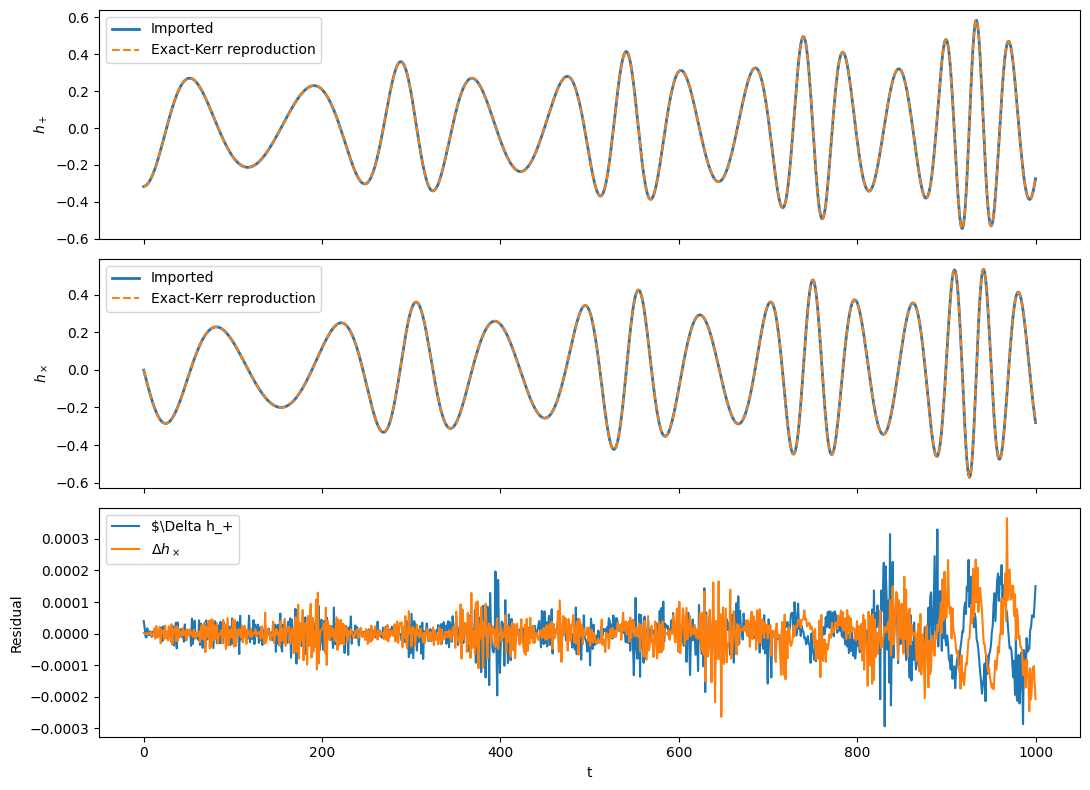

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (11,8), sharex=True)

ax[0].plot(t_test, h_plus_reference, label = "Imported", linewidth=2)
ax[0].plot(t_test, h_plus_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[0].set_ylabel(r"$h_+$")
ax[0].legend()

ax[1].plot(t_test, h_cross_reference, label = "Imported", linewidth = 2)
ax[1].plot(t_test, h_cross_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[1].set_ylabel(r"$h_\times$")
ax[1].legend()

ax[2].plot(t_test, (h_plus_gate - h_plus_reference).detach(), label = r"$\Delta h_+")
ax[2].plot(t_test, (h_cross_gate-h_cross_reference).detach(), label = r"$\Delta h_\times$")
ax[2].set_xlabel("t")
ax[2].set_ylabel("Residual")
ax[2].legend()

plt.tight_layout()

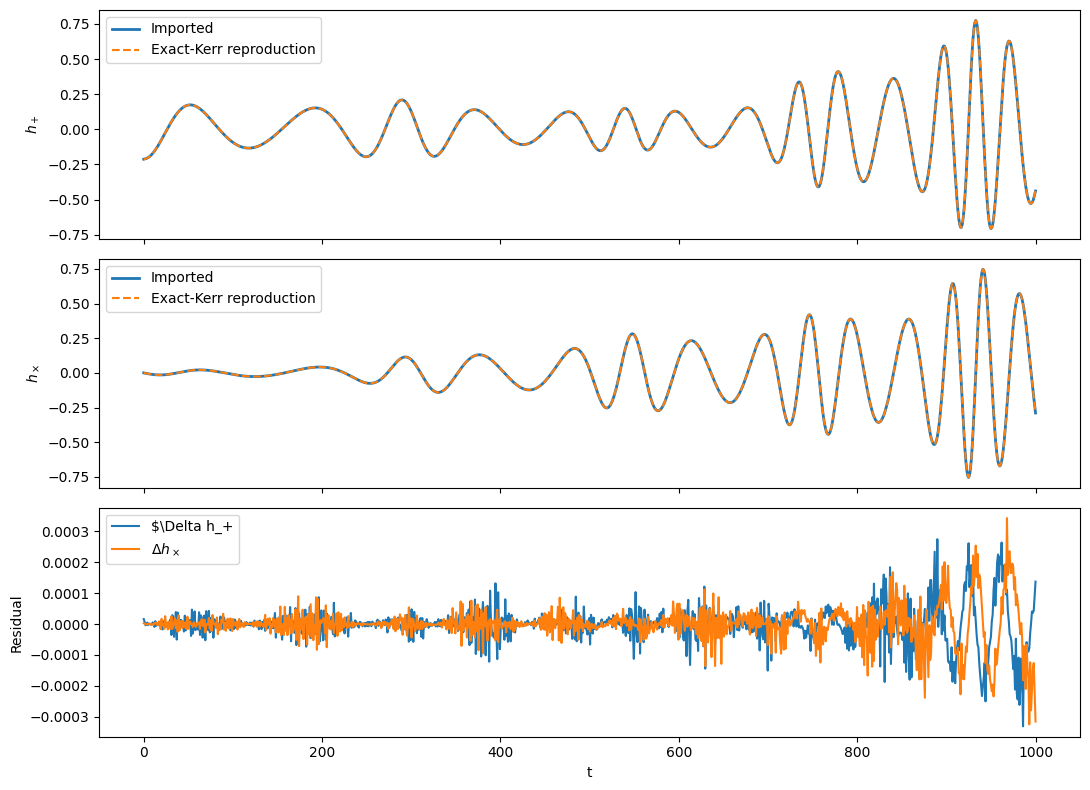

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (11,8), sharex=True)

ax[0].plot(t_test, h_plus_reference_2, label = "Imported", linewidth=2)
ax[0].plot(t_test, h_plus_gate_2.detach(), "--", label = "Exact-Kerr reproduction")
ax[0].set_ylabel(r"$h_+$")
ax[0].legend()

ax[1].plot(t_test, h_cross_reference_2, label = "Imported", linewidth = 2)
ax[1].plot(t_test, h_cross_gate_2.detach(), "--", label = "Exact-Kerr reproduction")
ax[1].set_ylabel(r"$h_\times$")
ax[1].legend()

ax[2].plot(t_test, (h_plus_gate_2 - h_plus_reference_2).detach(), label = r"$\Delta h_+")
ax[2].plot(t_test, (h_cross_gate_2-h_cross_reference_2).detach(), label = r"$\Delta h_\times$")
ax[2].set_xlabel("t")
ax[2].set_ylabel("Residual")
ax[2].legend()

plt.tight_layout()

# Ricci Loss Term

## Ricci Loss Term Components

In [ ]:
def christ_awful(metric, x):
  partial_g = torch.func.jacfwd(metric)(x)
  ginv = torch.linalg.inv(metric(x))
  term1 = torch.einsum("ms, sab->mab", ginv, partial_g)
  term2 = torch.einsum("ms, sba->mab", ginv, partial_g)
  term3 = torch.einsum("ms, abs->mab", ginv, partial_g)
  christoffel = 0.5 * (term1 + term2 - term3)
  return christoffel

In [ ]:
def Riemann(metric, x):
  dGamma = torch.func.jacfwd(christ_awful, argnums=1)(metric, x)
  term1 = torch.einsum("abvu->abuv", dGamma)
  term2 = torch.einsum("abuv->abuv", dGamma)
  term3 = torch.einsum("aup,pbv->abuv", christ_awful(metric, x), christ_awful(metric, x))
  term4 = torch.einsum("avp,pbu->abuv", christ_awful(metric, x), christ_awful(metric, x))
  Riemann = term1 - term2 + term3 - term4
  return Riemann

In [ ]:
def Ricci(metric, x):
  ricci = torch.einsum("abav->bv", Riemann(metric, x))
  return ricci

## Gate: Test on Exact Schwarzschild & Kerr Metrics

In [ ]:
def Schwarzschild(x, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  g_tt = -(1-2*M/r)
  g_rr = (1-2*M/r)**(-1)
  g_θθ = r**2
  g_ϕϕ = r**2 * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, zero])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([zero, zero, zero, g_ϕϕ])
  schild = torch.stack([row1, row2, row3, row4])
  return schild

In [ ]:
x = torch.tensor([0.0, 10.0, math.pi/2, 0.0])
input_spin = torch.tensor(0.9, dtype = x.dtype)
kerr_gate = lambda x: Kerr(x, a=input_spin)
schwarzschild_gate = lambda x: Schwarzschild(x)
print("Kerr Gate:", Ricci(kerr_gate, x))
print("\nSchwarzschild Gate:", Ricci(schwarzschild_gate, x))

Kerr Gate: tensor([[ 3.4925e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09, -3.3654e-16,  0.0000e+00],
        [ 0.0000e+00,  1.1484e-15,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7881e-07]])

Schwarzschild Gate: tensor([[-1.1642e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09,  8.8818e-16,  0.0000e+00],
        [ 0.0000e+00,  8.8818e-16,  1.4901e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4901e-08]])


# Frequency Loss Term

## Why `torch.angle()` fails

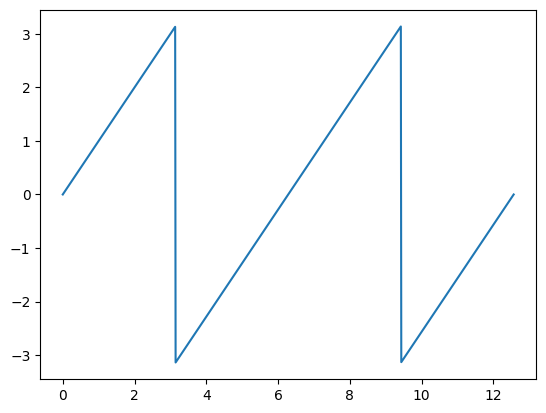

In [ ]:
θ = torch.linspace(0, 4*math.pi, 1000)
wrapped = torch.atan2(torch.sin(θ), torch.cos(θ))

plt.plot(θ, wrapped)

## $\omega=|h_{true}| * Im\frac{\dot h}{h+\epsilon}$

In [ ]:
def freq_loss(h_plus_pred, h_cross_pred, h_plus_true, h_cross_true, eps = 1e-12):
    h_pred = torch.complex(h_plus_pred, h_cross_pred)
    h_true = torch.complex(h_plus_true, h_cross_true)
    dt = assert_uniform_time(t_test)

    eps_power = 1e-4 * h_true.abs().square().mean().detach()

    def omega(h):
      z = h[:-1]
      dh = torch.diff(h) / dt
      return torch.imag(torch.conj(z) * dh) / (
          z.abs().square() + eps_power
      )

    omega_pred = omega(h_pred)
    omega_true = omega(h_true)
    weight = h_true[:-1].abs().square()

    raw = (weight * (omega_pred - omega_true).square()).mean()
    normalization = (weight * omega_true.square()).mean().detach()

    freqLoss = raw / (normalization + eps)
    return freqLoss, omega_true

## Gate: $L_{\omega}(h_{true},h_{true})=0$

In [ ]:
freq_loss(h_plus_true_obs1, h_cross_true_obs1, h_plus_true_obs1, h_cross_true_obs1)

(tensor(0.),
 tensor([0.0585, 0.0591, 0.0591, 0.0592, 0.0593, 0.0594, 0.0596, 0.0597, 0.0599,
         0.0601, 0.0604, 0.0606, 0.0609, 0.0611, 0.0614, 0.0616, 0.0619, 0.0621,
         0.0623, 0.0625, 0.0627, 0.0628, 0.0629, 0.0630, 0.0630, 0.0630, 0.0629,
         0.0628, 0.0626, 0.0624, 0.0621, 0.0618, 0.0615, 0.0611, 0.0607, 0.0603,
         0.0598, 0.0593, 0.0588, 0.0583, 0.0578, 0.0572, 0.0567, 0.0562, 0.0557,
         0.0552, 0.0547, 0.0543, 0.0538, 0.0534, 0.0530, 0.0526, 0.0523, 0.0520,
         0.0517, 0.0514, 0.0511, 0.0509, 0.0507, 0.0505, 0.0504, 0.0503, 0.0502,
         0.0501, 0.0500, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499,
         0.0499, 0.0499, 0.0499, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0499,
         0.0499, 0.0499, 0.0498, 0.0497, 0.0496, 0.0495, 0.0494, 0.0493, 0.0491,
         0.0489, 0.0487, 0.0485, 0.0483, 0.0481, 0.0478, 0.0476, 0.0473, 0.0470,
         0.0468, 0.0465, 0.0462, 0.0459, 0.0456, 0.0453, 0.0450, 0.0448, 0.0445,
         0.0442

## Gate: Kerr Circular, Equatorial Frequency $\Omega=\frac{M^{1/2}}{r^{3/2}+aM^{1/2}}$

Text(0.5, 1.0, 'Circular Kerr Orbit ($r=10$)')

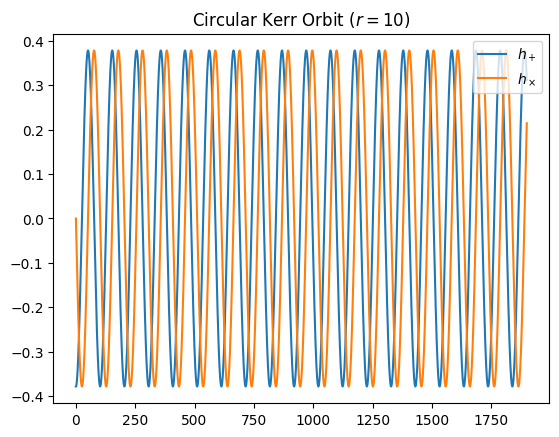

In [ ]:
t_true, h_plus_true_circle = np.loadtxt('circular_orbit_kerr_r=10_h_real.txt', unpack = True)
t_true, h_cross_true_circle = np.loadtxt('circular_orbit_kerr_r=10_h_imag.txt', unpack = True)

h_plus_true_circle = torch.tensor(h_plus_true_circle, dtype = torch.float32)
h_cross_true_circle = torch.tensor(h_cross_true_circle, dtype = torch.float32)

plt.plot(t_true, h_plus_true_circle, label = r"$h_+$")
plt.plot(t_true, h_cross_true_circle, label = r"$h_\times$")
plt.legend(loc = "upper right")
plt.title(r"Circular Kerr Orbit ($r=10$)")

In [ ]:
freq_loss(h_plus_true_obs1, h_cross_true_obs1, h_plus_true_circle[:t_final], h_cross_true_circle[:t_final])[1][:10]

tensor([0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073,
        0.0073])

# Boundary Condition Loss Term

## 4 Tricks: Square, Normalize, Exponentiate, and Weight

In [ ]:
import torch

def resid(metric, x):
    g_rr = metric(x)[1,1]
    g_rr_inv = 1/g_rr
    return g_rr_inv

def boundaryConditionLoss(metric):
  M = 1
  zero = torch.tensor(0.)
  r_vals = torch.linspace(1*M, 2.01*M, 10)
  θ_vals = torch.linspace(0, math.pi/2, 2)
  tau = 2e-3

  roots = []
  root_residuals = [] # g^{rr}(r_H, θ)^2 -- penalizes "no real zero here"
  sign_penalties = []


  for θ in θ_vals:
    badness_vals = []
    for r in r_vals:
      x = torch.stack([zero, r, θ, zero])
      badness = resid(metric, x)**2 # square it
      badness_vals.append(badness) # add it to the array

    weights = torch.softmax(-torch.stack(badness_vals)/tau, dim=0)
    weighted_average = (weights * r_vals).sum()
    roots.append(weighted_average)

    x_root = torch.stack([zero, weighted_average, θ, zero])
    root_residuals.append(resid(metric, x_root)**2)

    x_lo = torch.stack([zero, r_vals[0], θ, zero])
    x_hi = torch.stack([zero, r_vals[-1], θ, zero])
    sign_penalties.append(F.relu(resid(metric, x_lo) * resid(metric, x_hi))) # >0 only if same-sign (no crossing)

  location_consistency = torch.var(torch.stack(roots))
  zero_crossing_penalty = torch.stack(root_residuals).mean()
  sign_change_penalty = torch.stack(sign_penalties).mean()

  L2_norm_BC_loss = location_consistency + zero_crossing_penalty + sign_change_penalty

  return L2_norm_BC_loss, roots

## Gate: Kerr $a=0, r_H=1.43M$

In [ ]:
metric_fn = lambda x: Kerr(x, a = 0.9)
boundaryConditionLoss(metric_fn)

(tensor(6.8913e-05), [tensor(1.4287), tensor(1.4401)])

## Gate: Schwarzschild $a=0, r_H=2M$

In [ ]:
metric_fn = lambda x: Kerr(x, a = 0)
boundaryConditionLoss(metric_fn)

(tensor(3.4315e-05), [tensor(1.9884), tensor(1.9884)])

# Loss Function

Things to test:
- Exponential ricci grid sampling (i.e., `r_grid = 1 +. 10^([-3, 3, 10])`) so that near-Horizon is sampled more strongly than far-away
- A very good training log required to log / print out the weights of each loss term as they change, the predicted metric as it evolves during training, etc.

In [ ]:
import math
π = math.pi

P_WAVEFORM = 1.0
P_RICCI = 0.5
P_FREQUENCY = 0.1
P_BC = 0.1

# -------------------------------------------------------
# v10: Supervised Kerr Metric Loss
# -------------------------------------------------------

def loss(network, params_dict=None):
  ref = next(network.parameters()) # fetches the very first tensor (i.e., weight or bias) from a NN model
  # ^ this is often used to quickly check the hardware device (.device) or data type (.dtype) of the model
  radial_vals = torch.logspace(math.log10(2), math.log10(20), 10,
                               dtype=ref.dtype, device=ref.device)
  angular_vals = torch.linspace(π/20, π/2, 6,
                                dtype=ref.dtype, device=ref.device)

  component_indices = [
        (0, 0), # g_tt
        (1, 1), # g_rr
        (2, 2), # g_θθ
        (3, 3), # g_ϕϕ
        (0, 3), # g_tϕ
      ]

  losses_by_radius = []

  for r in radial_vals:
    pred_profile = []
    true_profile = []

    for θ in angular_vals:
      pred = metric_from_network(network, r, θ,
                                 params_dict=params_dict)
      true = g_Kerr(r, θ)

      pred_profile.append(torch.stack([
          pred[μ, ν] for μ, ν in component_indices
      ]))

      true_profile.append(torch.stack([
          true[μ, ν] for μ, ν in component_indices
      ]))

    pred_profile = torch.stack(pred_profile) # shape: [n_\theta, 5]
    true_profile = torch.stack(true_profile)

    # Relative squared L2 error across \theta
    numerator = (pred_profile - true_profile).square().sum(dim=0)
    denominator = true_profile.square().sum(dim=0)

    losses_by_radius.append(
        numerator / (denominator + 1e-12)
    )

  # Equal weight per radius, then equal weight per component
  component_losses = torch.stack(
      losses_by_radius
      ).mean(dim=0)
  L_K = component_losses.mean() # Kerr Loss

  return L_K, component_losses


# -------------------------------------------------------
# v9: Inverse Objective: Diagnostic only in v10
#     Never used to train v10
# -------------------------------------------------------

def inverse_loss(network):
  ref = next(network.parameters())

  r_grid = torch.logspace(
      math.log10(2.0), math.log10(20.0), 10,
      dtype = ref.dtype, device = ref.device
  )

  θ_grid = torch.linspace(
      π/20, π/2, 2,
      dtype = ref.dtype, device = ref.device
  )

  def g(x):
    return metric_from_network(network, x[1], x[2])

  ricci_terms = []

  for r in r_grid:
    for θ in θ_grid:
      zero = torch.zeros((), dtype = ref.dtype, device=ref.device)
      x = torch.stack([zero, r, θ, zero])
      ricci_terms.append(Ricci(g, x).square().sum())

  ricciLoss = torch.stack(ricci_terms).mean()

  waveformLoss, pred_h_real, pred_h_imag = waveform_loss(network)

  freq_Loss = torch.stack([
      freq_loss(
          pred_h_real[i],
          pred_h_imag[i],
          h_plus_true[i],
          h_cross_true[i]
      )[0]
      for i in range(len(θ_observed))
  ]).mean()

  boundaryCondition_Loss, roots = boundaryConditionLoss(g)

  total_loss = (
      P_WAVEFORM * waveformLoss
    + P_RICCI * ricciLoss
    + P_FREQUENCY * freq_Loss
    + P_BC * boundaryCondition_Loss
  )

  return (
      total_loss,
      waveformLoss,
      ricciLoss,
      freq_Loss,
      boundaryCondition_Loss,
      roots
  )

# Checkpoints

In [ ]:
import os
from google.colab import drive
drive.mount("/content/drive")

CHECKPOINT_PATH = "/content/drive/MyDrive/sonar_v10_cloud_new.pt"
V9_CHECKPOINT_PATH = "/content/drive/MyDrive/sonar_v9_cloud.pt"

def save_checkpoint(epoch, n, loss_history):
  torch.save({
      "net_state": net.state_dict(),
      "epoch": epoch,
      "n": n,
      "loss_history": loss_history,
  }, CHECKPOINT_PATH)

def load_checkpoint():
  if not os.path.exists(CHECKPOINT_PATH):
    return None

  return torch.load(CHECKPOINT_PATH,
                    map_location="cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Diagnostics Log

In [ ]:
# =====================================================================
# Sonar v10 diagnostics -- these were all created by an LLM, not Ref.
#
# These functions rely on names already defined in the notebook:
#   NN_Metric, net, loss, log_diagnostics, metric_from_network, g_Kerr,
#   waveform_loss, create_gravityWave, integrate, H_function, H_Kerr,
#   make_u0, rp_true, ra_true, θmin_true, a_true, t_test,
#   h_plus_true, h_cross_true, θ_observed
#
# So run it INSIDE the notebook namespace, not as an import:
#     exec(open("sonar_v11_diagnostics.py").read())
# or simply paste the whole file into one cell.
# =====================================================================

_PI = math.pi


def _dt_of(network):
    return next(network.parameters()).dtype


# =====================================================================
# D1.  Cross-evaluate a saved checkpoint under the v10 supervised loss
#      This is the decisive measurement: is L_K(θ_v9) small or large?
# =====================================================================

def evaluate_checkpoint_under_LK(path, label="v9"):
    if not os.path.exists(path):
        print(f"[{label}] checkpoint not found: {path}")
        return None

    try:
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location="cpu")

    state = ckpt["net_state"] if isinstance(ckpt, dict) and "net_state" in ckpt else ckpt

    target_dtype = torch.get_default_dtype()
    probe = NN_Metric().to(dtype=target_dtype)
    probe.load_state_dict({k: v.to(target_dtype) for k, v in state.items()})

    with torch.no_grad():
        L_K, comps = loss(probe)

    print(f"\n[{label}] scored under the v10 supervised Kerr loss")
    print(f"  L_K     = {L_K.item():.6e}")
    print(f"  E_total = {100 * math.sqrt(max(L_K.item(), 0.0)):.3f} %")
    for nm, c in zip(["g_tt", "g_rr", "g_θθ", "g_ϕϕ", "g_tϕ"], comps.tolist()):
        print(f"  E_{nm:5s}= {100 * math.sqrt(max(c, 0.0)):.3f} %")

    print(f"\n  reference: L_K(θ_K, v10 supervised optimum) = 9.150e-06")
    print("  << 9.15e-06  ->  v9 found a genuinely better metric (no degeneracy)")
    print("  >> 9.15e-06  ->  v9 sits in a spurious, phase-degenerate basin")

    log_diagnostics(probe, L_K, comps, 0, 0.0)
    return probe, L_K.item(), comps


# =====================================================================
# D2.  Hessian with eigenvectors, an empirical noise floor, and the
#      sloppy-valley overlap plot
# =====================================================================

def hessian_with_eigenbasis(network):
    names = [n for n, _ in network.named_parameters()]
    params = tuple(p.detach().clone().requires_grad_(True)
                   for p in network.parameters())

    def scalar_loss(*trial):
        return loss(network, params_dict=dict(zip(names, trial)))[0]

    blocks = torch.autograd.functional.hessian(scalar_loss, params, vectorize=True)

    rows = []
    for i, p_i in enumerate(params):
        rows.append(torch.cat(
            [blocks[i][j].reshape(p_i.numel(), params[j].numel())
             for j in range(len(params))], dim=1))
    H_raw = torch.cat(rows, dim=0)

    # The exact Hessian is symmetric, so any asymmetry is pure numerical
    # error. This is a direct, assumption-free estimate of the noise floor.
    noise = (H_raw - H_raw.T).abs().max().item()

    H = 0.5 * (H_raw + H_raw.T)
    lam, V = torch.linalg.eigh(H)
    return H.detach(), lam.detach(), V.detach(), noise


def spectrum_report(lam, noise):
    lam = lam.cpu()
    scale = lam.abs().max().item()
    tol = max(noise, 1e-8 * scale)

    pos = lam[lam > tol]
    neg = lam[lam < -tol]
    unres = lam[lam.abs() <= tol]

    print("\nSupervised L_K Hessian")
    print(f"  parameters                  : {len(lam)}")
    print(f"  |H - H^T|_max (noise floor) : {noise:.3e}")
    print(f"  resolution tolerance        : {tol:.3e}")
    print(f"  resolved positive           : {len(pos)}")
    print(f"  unresolved (|λ| <= tol)     : {len(unres)}")
    print(f"  resolved negative           : {len(neg)}")

    if len(neg):
        worst = neg.abs().max().item()
        print(f"  largest |negative|          : {worst:.3e}")
        verdict = ("REAL SADDLE - Adam did not reach a minimum"
                   if worst > 10 * tol else
                   "consistent with numerical noise, not a true saddle")
        print(f"  verdict                     : {verdict}")

    if len(pos) >= 2:
        print(f"  λ_max                       : {pos[-1].item():.4e}")
        print(f"  λ_min (resolved positive)   : {pos[0].item():.4e}")
        print(f"  condition number            : {(pos[-1] / pos[0]).item():.3e}")
        print(f"  decades spanned             : "
              f"{math.log10((pos[-1] / pos[0]).item()):.1f}")

    plt.figure(figsize=(7, 4))
    plt.semilogy(lam.abs().flip(0).numpy(), marker="o", ms=3, label="|λ|")
    plt.axhline(tol, color="r", ls="--", label="resolution floor")
    plt.xlabel("eigenvalue rank (sorted, descending)")
    plt.ylabel("|eigenvalue|")
    plt.title("L_K curvature spectrum  (straight line => sloppy)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return tol


def sloppy_valley_overlap(network, lam, V, tol):
    """
    Project ∇L_W and ∇L_K at θ_K onto the L_K curvature eigenbasis.

    If |V^T ∇L_W| concentrates where λ is SMALL, the waveform constrains
    exactly the directions the metric fit leaves free -> complementary,
    and the low-λ subspace is where v11 should spend its parameters.
    """
    network.zero_grad(set_to_none=True)
    L_W, _, _ = waveform_loss(network)
    gW = torch.cat([g.reshape(-1) for g in
                    torch.autograd.grad(L_W, list(network.parameters()))]).detach()

    network.zero_grad(set_to_none=True)
    L_K, _ = loss(network)
    gK = torch.cat([g.reshape(-1) for g in
                    torch.autograd.grad(L_K, list(network.parameters()))]).detach()

    cW = (V.T @ gW).abs().cpu()
    cK = (V.T @ gK).abs().cpu()
    lam_c = lam.cpu()

    order = torch.argsort(lam_c.abs())   # ascending: sloppiest first
    wW = (cW[order] ** 2)
    wW = wW / wW.sum().clamp_min(1e-300)
    half = len(lam_c) // 2

    print(f"\nSloppy-valley overlap at θ_K")
    print(f"  |∇L_W| = {gW.norm().item():.4e}")
    print(f"  |∇L_K| = {gK.norm().item():.4e}")
    print(f"  fraction of |∇L_W|² in the SLOPPIEST half of L_K's spectrum:"
          f" {wW[:half].sum().item():.3f}")
    print("  > 0.5  ->  objectives are complementary (good: waveform sees "
          "what L_K cannot)")
    print("  < 0.5  ->  objectives are redundant (bad: genuine degeneracy)")

    keep = lam_c.abs() > tol
    plt.figure(figsize=(7, 4.5))
    plt.loglog(lam_c[keep].abs().numpy(), cW[keep].numpy(),
               "o", ms=5, label=r"$|V^T \nabla L_W|$")
    plt.loglog(lam_c[keep].abs().numpy(), cK[keep].numpy(),
               "x", ms=5, label=r"$|V^T \nabla L_K|$")
    plt.xlabel(r"$L_K$ curvature eigenvalue $\lambda$")
    plt.ylabel("gradient component along that eigenvector")
    plt.title("Does the waveform constrain the sloppy directions?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return cW, cK, lam_c


# =====================================================================
# D3.  Hidden-unit utilisation - finds dead units and explains the
#      flat/near-null Hessian directions
# =====================================================================

def hidden_unit_audit(network):
    dt = _dt_of(network)
    r_grid = torch.logspace(math.log10(2), math.log10(20), 10, dtype=dt)
    θ_grid = torch.linspace(_PI / 20, _PI / 2, 6, dtype=dt)
    R, TH = torch.meshgrid(r_grid, θ_grid, indexing="ij")
    X = torch.stack([1.0 / R.reshape(-1), torch.cos(TH.reshape(-1)) ** 2], dim=1)

    with torch.no_grad():
        Hd = network.act(network.fc1(X))
        W2 = network.fc2.weight
        contrib = Hd.std(0) * W2.norm(dim=0)

    print("\nHidden-unit utilisation on the training grid")
    print(f"{'unit':>5} {'mean':>10} {'std':>10} {'range':>10} "
          f"{'||W2 col||':>11} {'contribution':>13}")
    for k in range(Hd.shape[1]):
        h = Hd[:, k]
        print(f"{k:5d} {h.mean():10.4f} {h.std():10.4f} "
              f"{(h.max() - h.min()):10.4f} {W2[:, k].norm():11.4f} "
              f"{contrib[k]:13.4e}")

    ratio = (contrib.max() / contrib.clamp_min(1e-30).min()).item()
    dead = (contrib < 0.1 * contrib.max()).nonzero().reshape(-1).tolist()
    print(f"\n  strongest/weakest contribution ratio : {ratio:.1f}")
    print(f"  units below 10% of the strongest      : {dead}")
    print(f"  effective width                       : "
          f"{Hd.shape[1] - len(dead)} of {Hd.shape[1]}")
    print("  A near-constant unit makes its 5 output weights degenerate with")
    print("  the output bias -> ~5 null directions in the Hessian.")
    return contrib, dead


# =====================================================================
# D4.  Physicality gates - cheap, run these during training
# =====================================================================

def physicality_report(network, r_probe=(2., 3., 5., 10., 14., 20., 100.),
                       verbose=True):
    dt = _dt_of(network)
    θs = [_PI / 20, _PI / 4, _PI / 3, 1.4]
    eq = torch.tensor(_PI / 2, dtype=dt)

    violations = []
    rows = []

    with torch.no_grad():
        for rv in r_probe:
            r = torch.tensor(float(rv), dtype=dt)
            base_p = metric_from_network(network, r, eq)[0, 0]
            base_t = g_Kerr(r, eq)[0, 0]
            dp, dtv = [], []
            for th in θs:
                t = torch.tensor(th, dtype=dt)
                dp.append((metric_from_network(network, r, t)[0, 0] - base_p).item())
                dtv.append((g_Kerr(r, t)[0, 0] - base_t).item())
            if max(dp) > 0:
                violations.append(rv)
            rows.append((rv, dp, dtv))

    if verbose:
        print("\nGATE 1  g_tt(r,θ) - g_tt(r,π/2) <= 0  for all θ   [Kerr identity]")
        hdr = " | ".join(f"θ={t:.2f}".rjust(11) for t in θs)
        print(f"{'r':>7} {'':>5} | {hdr}")
        for rv, dp, dtv in rows:
            flag = "FAIL" if max(dp) > 0 else "ok"
            print(f"{rv:7.0f} {'pred':>5} | " + " | ".join(f"{v:+.3e}" for v in dp)
                  + f"   {flag}")
            print(f"{'':7} {'true':>5} | " + " | ".join(f"{v:+.3e}" for v in dtv))

    # Gate 2: far-field angular contamination of g_tt
    if verbose:
        print("\nGATE 2  angular spread of M_eff must decay like a²/r²")
        print(f"{'r':>8} {'pred spread':>15} {'true spread':>15} {'ratio':>12}")
    ff = []
    with torch.no_grad():
        for rv in [20., 100., 1000.]:
            r = torch.tensor(rv, dtype=dt)
            Mp = torch.stack([network(nn_input(r, torch.tensor(t, dtype=dt)))[0] / 2
                              for t in θs])
            Mt = torch.stack([(1 + g_Kerr(r, torch.tensor(t, dtype=dt))[0, 0]) * r / 2
                              for t in θs])
            sp = (Mp.max() - Mp.min()).item()
            st = (Mt.max() - Mt.min()).item()
            ff.append((rv, sp, st))
            if verbose:
                print(f"{rv:8.0f} {sp:15.4e} {st:15.4e} {sp / max(st, 1e-30):11.0f}x")

    # Gate 3: Lorentzian signature outside the horizon
    bad_sig = []
    with torch.no_grad():
        for rv in r_probe:
            for th in θs + [_PI / 2]:
                r = torch.tensor(float(rv), dtype=dt)
                t = torch.tensor(float(th), dtype=dt)
                g = metric_from_network(network, r, t)
                if g[2, 2] <= 0 or g[1, 1] <= 0 or torch.linalg.det(g) >= 0:
                    bad_sig.append((rv, round(th, 3)))
    if verbose:
        print(f"\nGATE 3  signature (g_θθ>0, g_rr>0, det g<0) : "
              f"{'FAIL at ' + str(bad_sig) if bad_sig else 'ok'}")

    passed = (not violations) and (not bad_sig) and (ff[-1][1] < 10 * ff[-1][2])
    if verbose:
        print(f"\nPHYSICALITY: {'PASS' if passed else 'FAIL'}"
              + (f"   g_tt sign violated at r = {violations}" if violations else ""))

    return dict(gtt_violations=violations, far_field=ff,
                signature_failures=bad_sig, passed=passed)


# =====================================================================
# D5.  C0 / C1 / C2 error - the waveform depends on derivatives, L_K
#      only sees values
# =====================================================================

def _radial_derivs(metric_fn, r_val, dt, th_val=None):
    th_val = _PI / 2 if th_val is None else th_val
    r = torch.tensor(float(r_val), dtype=dt, requires_grad=True)
    th = torch.tensor(float(th_val), dtype=dt)
    g = metric_fn(r, th)
    c = {"tt": g[0, 0], "tp": g[0, 3], "pp": g[3, 3]}
    d1 = {k: torch.autograd.grad(v, r, create_graph=True, retain_graph=True)[0]
          for k, v in c.items()}
    d2 = {k: torch.autograd.grad(v, r, retain_graph=True)[0]
          for k, v in d1.items()}
    return ({k: v.detach() for k, v in c.items()},
            {k: v.detach() for k, v in d1.items()},
            {k: v.detach() for k, v in d2.items()})


def Omega_circ(metric_fn, r_val, dt):
    _, d1, _ = _radial_derivs(metric_fn, r_val, dt)
    disc = d1["tp"] ** 2 - d1["tt"] * d1["pp"]
    return ((-d1["tp"] + torch.sqrt(disc.clamp_min(0))) / d1["pp"]).item()


def sobolev_error_table(network, r_grid=(3., 5., 8., 10., 12., 14., 20.)):
    dt = _dt_of(network)
    pred = lambda r, th: metric_from_network(network, r, th)
    true = lambda r, th: g_Kerr(r, th)

    def rel(p, t):
        return 100 * abs(float(p) - float(t)) / max(abs(float(t)), 1e-30)

    print("\nC0 / C1 / C2 relative error in g_tt at θ=π/2, and in Ω")
    print(f"{'r':>5} {'|δg|%':>9} {'|δ∂g|%':>9} {'|δ∂²g|%':>10} "
          f"{'C1 amp':>8} {'C2 amp':>8} {'|δΩ|%':>9}")
    out = []
    for rv in r_grid:
        cp, d1p, d2p = _radial_derivs(pred, rv, dt)
        ct, d1t, d2t = _radial_derivs(true, rv, dt)
        e0 = rel(cp["tt"], ct["tt"])
        e1 = rel(d1p["tt"], d1t["tt"])
        e2 = rel(d2p["tt"], d2t["tt"])
        eO = rel(Omega_circ(pred, rv, dt), Omega_circ(true, rv, dt))
        print(f"{rv:5.0f} {e0:9.3f} {e1:9.3f} {e2:10.3f} "
              f"{e1 / max(e0, 1e-12):7.1f}x {e2 / max(e0, 1e-12):7.1f}x {eO:9.3f}")
        out.append((rv, e0, e1, e2, eO))
    print("  L_K only penalises the first column. The waveform depends on the")
    print("  third. Every derivative typically costs an order of magnitude.")
    return out


# =====================================================================
# D6.  Dephasing decomposition - where the phase error actually comes from
# =====================================================================

def _radial_period(r, t, t_max):
    r = np.asarray(r, dtype=float)
    t = np.asarray(t, dtype=float)
    m = t < t_max
    r, t = r[m], t[m]
    pk = [t[i] for i in range(1, len(r) - 1) if r[i] > r[i - 1] and r[i] > r[i + 1]]
    return float(np.mean(np.diff(pk))) if len(pk) > 1 else float("nan")


def dephasing_decomposition(network, stride=25):
    dt = _dt_of(network)
    params_dict = dict(network.named_parameters())
    u0 = make_u0(rp_true, ra_true, θmin_true)

    with torch.no_grad():
        traj_p = integrate(lambda tt, s: H_function(s, network, params_dict),
                           u0, t_test)
        traj_t = integrate(lambda tt, s: H_Kerr(s), u0, t_test)

    tn = t_test.detach().cpu().numpy()
    r_p, ph_p = traj_p[:, 1].cpu().numpy(), traj_p[:, 3].cpu().numpy()
    r_t, ph_t = traj_t[:, 1].cpu().numpy(), traj_t[:, 3].cpu().numpy()

    print("\nTRAJECTORY COMPARISON  (identical u0, predicted metric vs exact Kerr)")
    print(f"{'t':>7} {'r_true':>9} {'r_pred':>9} {'Δr':>10} "
          f"{'φ_true':>10} {'φ_pred':>10} {'ΔΦ_GW':>11}")
    for k in range(0, len(tn), max(1, len(tn) // 10)):
        print(f"{tn[k]:7.0f} {r_t[k]:9.4f} {r_p[k]:9.4f} {r_p[k] - r_t[k]:+10.5f} "
              f"{ph_t[k]:10.3f} {ph_p[k]:10.3f} {2 * (ph_p[k] - ph_t[k]):+11.4f}")

    total = 2 * (ph_p[-1] - ph_t[-1])

    # phase attributable to a frequency bias alone, evaluated on the TRUE r(t)
    step = float(tn[1] - tn[0])
    bias = 0.0
    for k in range(0, len(tn), stride):
        dOm = (Omega_circ(lambda r, th: metric_from_network(network, r, th),
                          r_t[k], dt)
               - Omega_circ(lambda r, th: g_Kerr(r, th), r_t[k], dt))
        bias += 2 * dOm * step * stride

    half = float(tn[-1]) * 0.5
    Pt = _radial_period(r_t, tn, half)
    Pp = _radial_period(r_p, tn, half)

    print("\nDECOMPOSITION")
    print(f"  total GW dephasing at t={tn[-1]:.0f}        : {total:+.3f} rad "
          f"({total / (2 * math.pi):+.3f} cycles)")
    print(f"  -- from frequency bias at true r(t) : {bias:+.3f} rad "
          f"({100 * abs(bias) / max(abs(total), 1e-30):.0f}%)")
    print(f"  -- from radial-trajectory error     : {total - bias:+.3f} rad "
          f"({100 * abs(total - bias) / max(abs(total), 1e-30):.0f}%)")
    print(f"\n  radial period   true = {Pt:.2f}   pred = {Pp:.2f}   "
          f"error = {100 * (Pp / Pt - 1):+.2f}%")
    print(f"  max |Δr|                            : "
          f"{np.abs(r_p - r_t).max():.4f}")

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(tn, r_t, label="r true")
    ax[0].plot(tn, r_p, "--", label="r predicted")
    ax[0].set_ylabel("r")
    ax[0].legend()
    ax[1].plot(tn, 2 * (ph_p - ph_t))
    ax[1].axhline(math.pi, color="r", ls=":", label="basin edge (π)")
    ax[1].axhline(-math.pi, color="r", ls=":")
    ax[1].set_ylabel(r"$\Delta\Phi_{GW}$ [rad]")
    ax[1].set_xlabel("t")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    return dict(total=total, bias=bias, P_true=Pt, P_pred=Pp)


# =====================================================================
# D7.  L_W as a phase meter, and the usable-window scan that sets the
#      v11 curriculum schedule
# =====================================================================

def phase_from_LW(L):
    """Invert L_W = 2(1 - cos ΔΦ).  Saturates: random phase -> 2, antiphase -> 4."""
    return math.acos(max(-1.0, min(1.0, 1.0 - L / 2.0)))


def phase_meter(values=None):
    values = values or [("exact Kerr", 6.653e-8),
                        ("v9 solution", 3.45e-5),
                        ("v10 supervised θ_K", 2.745)]
    print("\nL_W read as a phase meter:  L_W = 2(1 - cos ΔΦ)")
    print("  random relative phase -> 2.000     exact antiphase -> 4.000")
    for name, L in values:
        sat = "  [SATURATED - no usable gradient]" if L > 1.0 else ""
        print(f"  {name:24s} L_W={L:10.3e}  ->  ΔΦ ≈ {phase_from_LW(L):.4e} rad{sat}")


def usable_window_scan(network,
                       fractions=(0.02, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0)):
    dt = _dt_of(network)
    params_dict = dict(network.named_parameters())
    u0 = make_u0(rp_true, ra_true, θmin_true)

    with torch.no_grad():
        traj = integrate(lambda tt, s: H_function(s, network, params_dict),
                         u0, t_test)

    print("\nUSABLE-WINDOW SCAN  (integrate once, score on prefixes)")
    print(f"{'t_final':>9} {'N':>6} {'L_W':>12} {'ΔΦ [rad]':>11}  status")
    out = []
    for f in fractions:
        n = max(8, int(f * len(t_test)))
        tw = t_test[:n]
        terms = []
        with torch.no_grad():
            for i, th in enumerate(θ_observed):
                hp, hc = create_gravityWave(tw, traj[:n], a_true,
                                            θ_obs=th, ϕ_obs=0.0)
                se = ((hp - h_plus_true[i][:n]).square()
                      + (hc - h_cross_true[i][:n]).square()).mean()
                tp = (h_plus_true[i][:n].square()
                      + h_cross_true[i][:n].square()).mean()
                terms.append(se / (tp + 1e-12))
        L = torch.stack(terms).mean().item()
        dphi = phase_from_LW(L)
        status = ("INFORMATIVE" if L < 0.5 else
                  "marginal" if L < 1.5 else "SATURATED")
        print(f"{float(tw[-1]):9.0f} {n:6d} {L:12.4e} {dphi:11.4f}  {status}")
        out.append((float(tw[-1]), n, L, dphi))

    good = [o for o in out if o[2] < 0.5]
    if good:
        print(f"\n  longest window still informative at this metric accuracy: "
              f"t = {good[-1][0]:.0f}")
        print("  -> start the v11 curriculum at or below this, then extend as "
              "L_K improves.")
    else:
        print("\n  no window is informative: fix the metric before training on "
              "waveforms at all.")

    ts = [o[0] for o in out]
    Ls = [o[2] for o in out]
    plt.figure(figsize=(7, 4))
    plt.semilogy(ts, Ls, marker="o")
    plt.axhline(2.0, color="r", ls="--", label="decorrelation plateau")
    plt.axhline(0.5, color="g", ls=":", label="informative threshold")
    plt.xlabel("training window length  $t_{final}$")
    plt.ylabel("$L_W$")
    plt.title("Where the waveform loss goes blind")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return out


# =====================================================================
# OPTIONAL (not a diagnostic): Sobolev-augmented supervised loss.
# Drop-in replacement for loss() that penalises ∂_r error as well as
# value error. Roughly 2x the cost per evaluation.
# =====================================================================

def _fields_at(network, r, th, params_dict=None):
    g = metric_from_network(network, r, th, params_dict=params_dict)
    return torch.stack([g[0, 0], g[1, 1], g[2, 2], g[3, 3], g[0, 3]])


def _fields_true(r, th):
    g = g_Kerr(r, th)
    return torch.stack([g[0, 0], g[1, 1], g[2, 2], g[3, 3], g[0, 3]])


def loss_sobolev(network, w_grad=1.0, params_dict=None):
    ref = next(network.parameters())
    radial_vals = torch.logspace(math.log10(2), math.log10(20), 10,
                                 dtype=ref.dtype, device=ref.device)
    angular_vals = torch.linspace(_PI / 20, _PI / 2, 6,
                                  dtype=ref.dtype, device=ref.device)

    val_terms, grad_terms = [], []
    for r in radial_vals:
        pv, tv, pg, tg = [], [], [], []
        for th in angular_vals:
            pv.append(_fields_at(network, r, th, params_dict))
            tv.append(_fields_true(r, th))
            pg.append(torch.func.jacfwd(
                lambda rr: _fields_at(network, rr, th, params_dict))(r))
            tg.append(torch.func.jacfwd(lambda rr: _fields_true(rr, th))(r))

        pv, tv = torch.stack(pv), torch.stack(tv)
        pg, tg = torch.stack(pg), torch.stack(tg)

        val_terms.append((pv - tv).square().sum(0) / (tv.square().sum(0) + 1e-12))
        grad_terms.append((pg - tg).square().sum(0) / (tg.square().sum(0) + 1e-12))

    val_c = torch.stack(val_terms).mean(0)
    grad_c = torch.stack(grad_terms).mean(0)
    L = val_c.mean() + w_grad * grad_c.mean()
    return L, val_c, grad_c

In [ ]:
from prettytable import PrettyTable
import time

def rel_L2_error(pred, true, eps = 1e-12):
  return 100 * torch.sqrt(
                          torch.sum((pred - true) ** 2) / (torch.sum((true) ** 2) + eps)
                         )

# -------- Psuedo-code structure --------
# for each radius:
  # evaluate predicted metric at each \theta on a grid [π/20, π/4, π/3, π/2]
  # stack the \theta-profile of the metrics into a tensor of shape [n_theta, 4, 4]
  # compute L2 error for each metric component (i.e., g_tt, g_rr, etc.) across all theta values via L2(g_pred[:, \mu, \nu], g_true[:, \mu, \nu])
  # add that relative angular-profile error at a given radius for a given metric component as a row to the diagnostics table

def log_diagnostics(
    network, L_K,
    component_losses,
    iteration,
    elapsed_time
  ):

  r_grid = [2, 3, 4, 5, 6, 12, 20] # Use these explicit r values
  θ_grid = [π/20, π/4, π/3, π/2] # Use these explicit θ values

  gtt_error_vals = []
  grr_error_vals = []
  gθθ_error_vals = []
  gϕϕ_error_vals = []
  gtϕ_error_vals = []

  param = next(network.parameters())

  for r_val in r_grid:
    pred_vec = []
    true_vec = []

    for θ in θ_grid:
      r_t = torch.tensor(r_val, dtype = param.dtype, device = param.device)
      θ_t = torch.tensor(θ, dtype = param.dtype, device = param.device)

      pred_g = metric_from_network(network, r_t, θ_t)
      true_g = g_Kerr(r_t, θ_t)

      pred_vec.append(pred_g)
      true_vec.append(true_g)

    pred_vec = torch.stack(pred_vec)
    true_vec = torch.stack(true_vec)

    gtt_error_vals.append(rel_L2_error(pred_vec[:, 0, 0], true_vec[:, 0, 0]).detach().item())
    grr_error_vals.append(rel_L2_error(pred_vec[:, 1, 1], true_vec[:, 1, 1]).detach().item())
    gθθ_error_vals.append(rel_L2_error(pred_vec[:, 2, 2], true_vec[:, 2, 2]).detach().item())
    gϕϕ_error_vals.append(rel_L2_error(pred_vec[:, 3, 3], true_vec[:, 3, 3]).detach().item())
    gtϕ_error_vals.append(rel_L2_error(pred_vec[:, 0, 3], true_vec[:, 0, 3]).detach().item())

  metric_table = PrettyTable()
  metric_table.title = "Metric Relative L2 Error Across θ (%)"
  metric_table.field_names = [
      "Component",
      *[f"r={r_val}" for r_val in r_grid]
  ]

  metric_table.add_row(["g_tt", *gtt_error_vals])
  metric_table.add_row(["g_rr", *grr_error_vals])
  metric_table.add_row(["g_θθ", *gθθ_error_vals])
  metric_table.add_row(["g_ϕϕ", *gϕϕ_error_vals])
  metric_table.add_row(["g_tϕ", *gtϕ_error_vals])
  metric_table.float_format = ".2"

  component_percent = (
      100 * torch.sqrt(component_losses.detach())
  ).cpu().tolist()

  aggregate_percent = (
      100 * torch.sqrt(L_K.detach())
  ).item()

  print(
      f"iter={iteration:4d} | "
      f"time={elapsed_time:7.1f}s | "
      f"L_K={L_K.detach().item():.3e} | "
      f"E_total={aggregate_percent:6.2f}% | "
      f"E_tt={component_percent[0]:6.2f}% | "
      f"E_rr={component_percent[1]:6.2f}% | "
      f"E_θθ={component_percent[2]:6.2f}% | "
      f"E_ϕϕ={component_percent[3]:6.2f}% | "
      f"E_tϕ={component_percent[4]:6.2f}%"
  )

  print(metric_table)

  return metric_table

# Training

In [ ]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
import scipy.optimize._minimize as scipy_dispatch

scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize as minimize_ssbroyden

In [ ]:
loss_history = []

n = 0
start_epoch = 0

ckpt = load_checkpoint()

if ckpt is not None:
  # Preserve float64 BFGS checkpoints instead of silently casting through float32.
  checkpoint_dtype = next(iter(ckpt["net_state"].values())).dtype

  if checkpoint_dtype == torch.float64:
    net = net.to(dtype=torch.float64)

  net.load_state_dict(ckpt["net_state"])

  n = ckpt["n"]
  loss_history = ckpt["loss_history"]
  start_epoch = ckpt["epoch"] + 1

  print(f"Resumed from epoch {start_epoch}, n={n}")

# Retained for the post-training inverse-objective audit
t_full = t.detach().clone()
hp_full = [h_plus_true_obs1, h_plus_true_obs2]
hc_full = [h_cross_true_obs1, h_cross_true_obs2]

optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
start_time = time.time()
last_epoch = start_epoch - 1

for epoch in range(start_epoch, 1000):
  last_epoch = epoch
  optimizer.zero_grad()

  L_K, component_losses = loss(net)
  L_K.backward()

  torch.nn.utils.clip_grad_norm_(
      net.parameters(),
      1.0,
      error_if_nonfinite=True
  )

  optimizer.step()

  loss_history.append(L_K.detach().item())
  n += 1

  if n % 10 == 0:
    # recompute after optimizer.step(), keeping scalar and table consistent.
    with torch.no_grad():
      L_K_log, component_losses_log = loss(net)

      log_diagnostics(net,
                      L_K_log,
                      component_losses_log,
                      n,
                      time.time() - start_time)
      phys = physicality_report(net, verbose=False)
    if not phys["passed"]:
      print(f"  PHYSICALITY FAIL: g_tt sign violated at r = {phys['gtt_violations']}")

    save_checkpoint(last_epoch, n, loss_history)

save_checkpoint(last_epoch, n, loss_history)

print(f"Adam complete: {n} total iterations")

iter=  10 | time=    1.5s | L_K=1.229e+00 | E_total=110.88% | E_tt=220.14% | E_rr= 41.24% | E_θθ=  2.87% | E_ϕϕ= 10.11% | E_tϕ=105.82%
+--------------------------------------------------------------------------+
|                  Metric Relative L2 Error Across θ (%)                   |
+-----------+--------+--------+--------+--------+--------+--------+--------+
| Component |  r=2   |  r=3   |  r=4   |  r=5   |  r=6   |  r=12  |  r=20  |
+-----------+--------+--------+--------+--------+--------+--------+--------+
|    g_tt   | 681.33 | 130.24 | 69.92  | 47.63  | 36.07  | 14.62  |  8.14  |
|    g_rr   | 79.35  | 56.18  | 43.05  | 34.78  | 29.15  | 14.72  |  8.85  |
|    g_θθ   |  6.92  |  3.27  |  1.88  |  1.22  |  0.85  |  0.22  |  0.08  |
|    g_ϕϕ   | 25.54  | 11.31  |  6.05  |  3.69  |  2.47  |  0.54  |  0.18  |
|    g_tϕ   | 108.26 | 106.95 | 106.28 | 105.87 | 105.59 | 104.89 | 104.60 |
+-----------+--------+--------+--------+--------+--------+--------+--------+
  PHYSICALITY FAIL

## Float64 BFGS handoff


In [ ]:
def switch_to_float64_for_bfgs():
  global net, t_full, hp_full, hc_full
  global t_test, h_plus_true, h_cross_true

  # New tensors created inside ODE/Ricci/BC code now default to float64.
  torch.set_default_dtype(torch.float64)

  net = net.to(dtype=torch.float64)
  t_full = t_full.to(dtype=torch.float64)

  hp_full = [
      hp.to(dtype=torch.float64) for hp in hp_full
  ]

  hc_full = [
      hc.to(dtype=torch.float64) for hc in hc_full
  ]

  t_test = t_full
  h_plus_true = hp_full
  h_cross_true = hc_full

  assert next(net.parameters()).dtype == torch.float64
  assert t_full.dtype == torch.float64
  assert all(h.dtype == torch.float64 for h in hp_full + hc_full)

  print("BFGS precision:", next(net.parameters()).dtype)

switch_to_float64_for_bfgs()

# One diagnostic at the Adam→BFGS handoff.
L_K, component_losses = loss(net)

print(
    f"BFGS handoff: L_K={L_K.detach().item():.3e}"
)

BFGS precision: torch.float64
BFGS handoff: L_K=2.787e-04


In [ ]:
def as_float(x):
  return float(x.detach().cpu()) if torch.is_tensor(x) else float(x)

In [ ]:
def loss_and_gradient(x, reject_bad=True):
  ref = next(net.parameters())
  x_t = torch.as_tensor(x, dtype=ref.dtype, device=ref.device)

  with torch.no_grad():
    torch.nn.utils.vector_to_parameters(x_t, net.parameters())

  net.zero_grad(set_to_none=True)

  try:
    L, component_losses = loss(net)

    if not torch.isfinite(L):
      raise FloatingPointError

    L.backward()
    grad = torch.nn.utils.parameters_to_vector(
        [p.grad for p in net.parameters()]
    )

    if not torch.isfinite(grad).all():
      raise FloatingPointError

    loss_history.append(L.item())

    return(
        float(L.detach().cpu()),
        grad.detach().cpu().numpy().astype(np.float64),
    )

  except (RuntimeError, FloatingPointError) as e:
    if not reject_bad:
        raise
    return 1e30, np.zeros_like(x, dtype=np.float64)

def ssbroyden_callback(intermediate_result):
  with torch.no_grad():
    ref = next(net.parameters())
    accepted_x = torch.as_tensor(
        intermediate_result.x,
        dtype=ref.dtype,
        device=ref.device
    )
    torch.nn.utils.vector_to_parameters(
        accepted_x,
        net.parameters()
    )

  save_checkpoint(
        last_epoch,
        n,
        loss_history
  )

  elapsed = time.time() - bfgs_start_time

  print(
      "BFGS Loss:", intermediate_result.fun,
      "evaluations:", getattr(intermediate_result, "nfev", "?"),
      "elapsed:", elapsed
  )

x0 = (
    torch.nn.utils.parameters_to_vector(net.parameters())
    .detach().cpu().numpy().astype(np.float64)
)

t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

In [ ]:
def run_bfgs_stage(maxiter):
  global t_test, h_plus_true, h_cross_true

  t_test = t_full

  x0 = (
      torch.nn.utils.parameters_to_vector(net.parameters())
      .detach()
      .cpu()
      .numpy()
      .astype(np.float64)
  )

  # Strict handoff gate
  gate_loss, gate_grad = loss_and_gradient(
      x0,
      reject_bad=False
  )

  grad_norm = np.linalg.norm(gate_grad)

  print(
      f"loss={gate_loss:.3e}, "
      f"|grad|={grad_norm:.3e}, "
      f"finite_grad={np.isfinite(gate_grad).all()}"
  )

  assert(
      np.isfinite(x0).all() # adam did not corrupt parameters
      and np.isfinite(gate_loss) # objective evaluable
      and gate_loss < 1e29 # did not receive rejection sentinel 1e30
      and np.isfinite(gate_grad).all() # every derivative valid
      and grad_norm > 1e-12 # BFGS has meaningful direction
  ), "Invalid BFGS handoff: parameters, loss, or gradient are nonfinite/degenerate"

  result = minimize_ssbroyden(
      loss_and_gradient,
      x0,
      jac=True,
      method="BFGS",
      callback=ssbroyden_callback,
      options={
          "maxiter": maxiter,
          "gtol": 1e-9,
          "method_bfgs": "SSBroyden2",
          "initial_scale": False,
          "disp": True,
      },
  )

  with torch.no_grad():
    ref = next(net.parameters())
    final_x = torch.as_tensor(
        result.x,
        dtype=ref.dtype,
        device=ref.device,
    )
    torch.nn.utils.vector_to_parameters(
        final_x,
        net.parameters(),
    )

  print(
      f"loss={result.fun:.3e}, "
      f"iters={result.nit}, "
      f"evals={result.nfev}\n"
  )

  return result

bfgs_start_time = time.time()
result = run_bfgs_stage(10000)

bfgs_elapsed = time.time() - bfgs_start_time
total_elapsed = time.time() - start_time

print("\nBFGS Summary")
print("success:", result.success)
print("status:", result.status)
print("message:", result.message)
print("iterations:", result.nit)
print("function evaluations", result.nfev)
print("gradient evaluations", result.njev)
print("final loss:", result.fun)
print("BFGS elapsed:", bfgs_elapsed / 60, "minutes")
print("total Adam+BFGS elapsed:", total_elapsed / 60, "minutes")

if hasattr(result, "jac"):
  print("final ||gradient||:", np.linalg.norm(result.jac, ord=np.inf))
if "precision loss" in str(result.message).lower():
  print(
      "Precision loss remains in float64. "
      "Check ODE tolerances and objective smoothness before raising maxiter."
  )

loss=2.787e-04, |grad|=3.696e-04, finite_grad=True
BFGS Loss: 0.0002761419429203339 evaluations: 4 elapsed: 0.36182498931884766
BFGS Loss: 0.0002715998645226838 evaluations: 5 elapsed: 0.4364008903503418
BFGS Loss: 0.00026391939555378915 evaluations: 6 elapsed: 0.527979850769043
BFGS Loss: 0.0002524577160422721 evaluations: 7 elapsed: 0.6078023910522461
BFGS Loss: 0.00024919257813644336 evaluations: 8 elapsed: 0.6836071014404297
BFGS Loss: 0.00024342425985460553 evaluations: 9 elapsed: 0.7598867416381836
BFGS Loss: 0.00023252578686081219 evaluations: 10 elapsed: 0.8420460224151611
BFGS Loss: 0.00021348310838118474 evaluations: 11 elapsed: 0.9190337657928467
BFGS Loss: 0.0001951821003720452 evaluations: 12 elapsed: 1.0125579833984375
BFGS Loss: 0.00019091419591071192 evaluations: 14 elapsed: 1.1591944694519043
BFGS Loss: 0.00018593002382056477 evaluations: 15 elapsed: 1.2416188716888428
BFGS Loss: 0.00017657588437098285 evaluations: 16 elapsed: 1.3164021968841553
BFGS Loss: 0.0001587978

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


# Results

In [ ]:
t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

# -------------------------------------------
# A. Final supervised Kerr accuracy
# -------------------------------------------
final_LK, final_component_losses = loss(net)

log_diagnostics(
    net,
    final_LK,
    final_component_losses,
    n + result.nit,
    time.time() - start_time
)

evaluate_checkpoint_under_LK(
    V9_CHECKPOINT_PATH,
    label="v9"
)

# -------------------------------------------------------
# B. Full inverse objective at θ_K
# Do NOT use torch.no_grad(): Ricci requires derivatives
# -------------------------------------------------------
inverse_total, inverse_W, inverse_R, inverse_F, inverse_BC, inverse_roots = (
    inverse_loss(net)
)

predicted_r_H = torch.stack(inverse_roots).mean()
waveform_percent = 100 * torch.sqrt(inverse_W)

print("\nInverse objective evaluated at supervised optimum θ_K")
print(f"L_inverse = {inverse_total.detach().item():.6e}")
print(f"L_W = {inverse_W.detach().item():.6e}")
print(f"L_R = {inverse_R.detach().item():.6e}")
print(f"L_F = {inverse_F.detach().item():.6e}")
print(f"L_BC = {inverse_BC.detach().item():.6e}")
print(f"W_error = {waveform_percent.detach().item():.3f}%")
print(f"r_H = {predicted_r_H.detach().item():.6f}")

print("\nWeighted contributions")
print(f"W = {(P_WAVEFORM * inverse_W).detach().item():.6e}")
print(f"R = {(P_RICCI * inverse_R).detach().item():.6e}")
print(f"F = {(P_FREQUENCY * inverse_F).detach().item():.6e}")
print(f"BC = {(P_BC * inverse_BC).detach().item():.6e}")

V9_WAVEFORM_LOSS = 3.45e-5

print(
    "\nL_W(θ_K) / L_W(θ_v9) =",
    inverse_W.detach().item() / V9_WAVEFORM_LOSS
)


iter=1734 | time=  171.7s | L_K=2.024e-08 | E_total=  0.01% | E_tt=  0.02% | E_rr=  0.01% | E_θθ=  0.01% | E_ϕϕ=  0.00% | E_tϕ=  0.01%
+------------------------------------------------------------+
|           Metric Relative L2 Error Across θ (%)            |
+-----------+------+------+------+------+------+------+------+
| Component | r=2  | r=3  | r=4  | r=5  | r=6  | r=12 | r=20 |
+-----------+------+------+------+------+------+------+------+
|    g_tt   | 0.01 | 0.04 | 0.02 | 0.03 | 0.02 | 0.01 | 0.02 |
|    g_rr   | 0.01 | 0.02 | 0.01 | 0.02 | 0.02 | 0.01 | 0.01 |
|    g_θθ   | 0.01 | 0.00 | 0.01 | 0.00 | 0.00 | 0.01 | 0.00 |
|    g_ϕϕ   | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
|    g_tϕ   | 0.02 | 0.02 | 0.02 | 0.01 | 0.01 | 0.01 | 0.02 |
+-----------+------+------+------+------+------+------+------+
[v9] checkpoint not found: /content/drive/MyDrive/sonar_v9_cloud.pt

Inverse objective evaluated at supervised optimum θ_K
L_inverse = 1.829361e-03
L_W = 1.331372e-03
L_R =

In [ ]:
def normalized_waveform_loss_from_arrays(
    pred_plus, pred_cross,
    true_plus, true_cross,
    eps=1e-12):

  terms = []

  for pp, pc, tp, tc in zip(
      pred_plus, pred_cross,
      true_plus, true_cross):
    squared_error = (
        (pp - tp).square()
      + (pc - tc).square()
    ).mean()

    truth_power = (
        tp.square() + tc.square()
    ).mean()

    terms.append(
        squared_error / (truth_power + eps)
    )

  return torch.stack(terms).mean()

def exact_kerr_physics_floor():
  ref = next(net.parameters())

  r_grid = torch.logspace(
      math.log10(2.0), math.log10(20.0), 10,
      dtype=ref.dtype, device=ref.device
  )

  θ_grid = torch.linspace(
      π/20, π/2, 2,
      dtype=ref.dtype, device=ref.device
  )

  def exact_metric(x):
    return g_Kerr(x[1], x[2])

  ricci_terms = []

  for r in r_grid:
    for θ in θ_grid:
      zero = torch.zeros((), dtype=ref.dtype, device=ref.device)
      x = torch.stack([zero, r, θ, zero])
      ricci_terms.append(
          Ricci(exact_metric, x).square().sum()
      )

  exact_R = torch.stack(ricci_terms).mean()
  exact_BC, exact_roots = boundaryConditionLoss(exact_metric)
  exact_r_H = torch.stack(exact_roots).mean()

  return exact_R, exact_BC, exact_r_H

ref = next(net.parameters())

gate_plus = [
    h_plus_gate.to(dtype=ref.dtype),
    h_plus_gate_2.to(dtype=ref.dtype)
]

gate_cross = [
    h_cross_gate.to(dtype=ref.dtype),
    h_cross_gate_2.to(dtype=ref.dtype)
]

exact_W = normalized_waveform_loss_from_arrays(
    gate_plus,
    gate_cross,
    hp_full,
    hc_full
)

exact_F = torch.stack([
    freq_loss(
        gate_plus[i],
        gate_cross[i],
        hp_full[i],
        hc_full[i]
    )[0]
    for i in range(len(θ_observed))
]).mean()

exact_R, exact_BC, exact_r_H = exact_kerr_physics_floor()

exact_total = (
    P_WAVEFORM * exact_W
  + P_RICCI * exact_R
  + P_FREQUENCY * exact_F
  + P_BC * exact_BC
)

print("\nExact Kerr through the same discretized objective")

print(f"L_total = {exact_total.detach().item():.6e}")
print(f"L_W = {exact_W.detach().item():.6e}")
print(f"L_R = {exact_R.detach().item():.6e}")
print(f"L_F = {exact_F.detach().item():.6e}")
print(f"L_BC = {exact_BC.detach().item():.6e}")
print(f"r_H = {exact_r_H.detach().item():.6f}")



Exact Kerr through the same discretized objective
L_total = 7.437568e-06
L_W = 6.653473e-08
L_R = 3.756274e-29
L_F = 4.795991e-06
L_BC = 6.891435e-05
r_H = 1.434426


In [ ]:
def print_far_field_coefficients(network):
  ref = next(network.parameters())

  θ_values = torch.tensor(
      [π/20, π/4, π/3, π/2],
      dtype = ref.dtype,
      device = ref.device
  )

  with torch.no_grad():
    for r_value in [20.0, 100.0]:
      r = torch.tensor(
          r_value,
          dtype=ref.dtype,
          device=ref.device
      )

      M_values = []
      J_values = []

      for θ in θ_values:
        fields = network(nn_input(r, θ))

        # g_tt = -1 + 2M/r
        M_values.append(fields[0] / 2)

        # g_t\phi = -2J/r * sin^2\theta
        J_values.append(-fields[4] / 2)

      M_values = torch.stack(M_values)
      J_values = torch.stack(J_values)

      print(
          f"r={r_value:5.1f} | "
          f"M_eff={M_values.mean().item():6f} | "
          f"± {M_values.std(unbiased=False).item():2e} | "
          f"J_eff={J_values.mean().item():.6f} "
          f"± {J_values.std(unbiased=False).item():.2e}"
      )

      print("Kerr truth: M = 1.00000, J=Ma=0.9000000")

print_far_field_coefficients(net)

r= 20.0 | M_eff=1.000126 | ± 2.798417e-04 | J_eff=0.899129 ± 1.03e-03
Kerr truth: M = 1.00000, J=Ma=0.9000000
r=100.0 | M_eff=1.002340 | ± 2.137184e-03 | J_eff=0.900513 ± 5.37e-04
Kerr truth: M = 1.00000, J=Ma=0.9000000



Supervised L_K Hessian
parameters: 69
positive directions: 54
flat directions: 5
negative directions: 10
largest eigenvalue: 6.489728803358039
smallest positive eigenvalue: 1.307019956693975e-09
condition number: 4965286696.748994


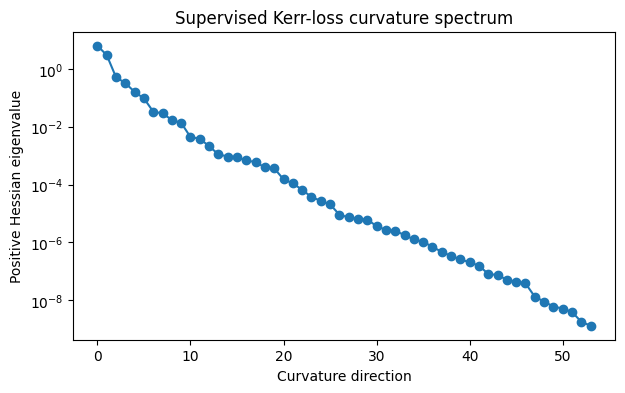


Supervised L_K Hessian
  parameters                  : 69
  |H - H^T|_max (noise floor) : 1.665e-16
  resolution tolerance        : 6.490e-08
  resolved positive           : 44
  unresolved (|λ| <= tol)     : 20
  resolved negative           : 5
  largest |negative|          : 1.297e-06
  verdict                     : REAL SADDLE - Adam did not reach a minimum
  λ_max                       : 6.4897e+00
  λ_min (resolved positive)   : 7.4586e-08
  condition number            : 8.701e+07
  decades spanned             : 7.9


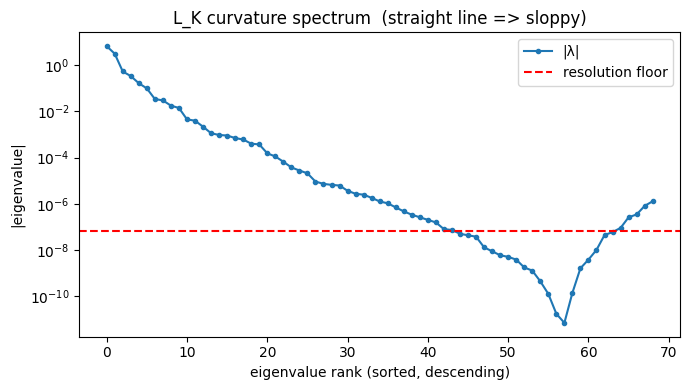


Sloppy-valley overlap at θ_K
  |∇L_W| = 1.6801e+01
  |∇L_K| = 4.1773e-06
  fraction of |∇L_W|² in the SLOPPIEST half of L_K's spectrum: 0.000
  > 0.5  ->  objectives are complementary (good: waveform sees what L_K cannot)
  < 0.5  ->  objectives are redundant (bad: genuine degeneracy)


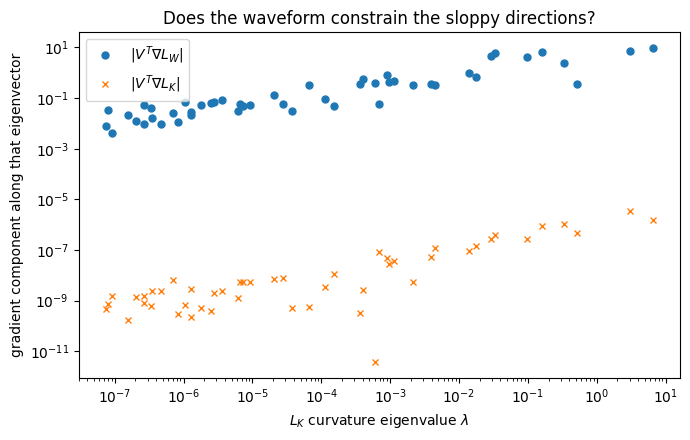

In [ ]:
def supervised_hessian_spectrum(network):
  names = [
      name for name, _ in network.named_parameters()
  ]

  params = tuple(
      p.detach().clone().requires_grad_(True)
      for p in network.parameters()
  )

  def scalar_loss(*trial_params):
    params_dict = dict(zip(names, trial_params))

    return loss(
        network,
        params_dict=params_dict
    )[0]

  blocks = torch.autograd.functional.hessian(
      scalar_loss,
      params,
      vectorize=True
  )

  rows = []

  for i, p_i in enumerate(params):
    row = torch.cat([
        blocks[i][j].reshape(
            p_i.numel(),
            params[j].numel()
        )
        for j in range(len(params))
    ], dim=1)

    rows.append(row)

  H = torch.cat(rows, dim=0)
  H = 0.5 * (H + H.T)

  eigenvalues = torch.linalg.eigvalsh(H).detach()

  scale = eigenvalues.abs().max().clamp_min(
      torch.finfo(eigenvalues.dtype).eps
  )

  tolerance = 1e-10 * scale

  positive = eigenvalues[eigenvalues > tolerance]
  negative = eigenvalues[eigenvalues < -tolerance]
  flat = eigenvalues[eigenvalues.abs() <= tolerance]

  print("\nSupervised L_K Hessian")
  print("parameters:", H.shape[0])
  print("positive directions:", len(positive))
  print("flat directions:", len(flat))
  print("negative directions:", len(negative))

  if len(positive) >= 2:
    condition_number = (
        positive[-1] / positive[0]
    ).item()

    print("largest eigenvalue:", positive[-1].item())
    print("smallest positive eigenvalue:", positive[0].item())
    print("condition number:", condition_number)

    plt.figure(figsize=(7,4))
    plt.semilogy(
        positive.flip(0).cpu(),
        marker="o"
    )
    plt.xlabel("Curvature direction")
    plt.ylabel("Positive Hessian eigenvalue")
    plt.title("Supervised Kerr-loss curvature spectrum")
    plt.show()

  return eigenvalues, H

hessian_eigenvalues, supervised_H = (
    supervised_hessian_spectrum(net)
)

supervised_H, hessian_eigenvalues, hessian_V, hessian_noise = hessian_with_eigenbasis(net)
hessian_tol = spectrum_report(hessian_eigenvalues, hessian_noise)
cW, cK, lam = sloppy_valley_overlap(net, hessian_eigenvalues, hessian_V, hessian_tol)

In [ ]:
hidden_unit_audit(net)


Hidden-unit utilisation on the training grid
 unit       mean        std      range  ||W2 col||  contribution
    0     0.1509     0.4050     1.7209      0.8695    3.5210e-01
    1     0.8125     0.0742     0.2465      2.9915    2.2194e-01
    2    -0.1518     0.2319     1.1005      0.2664    6.1760e-02
    3    -0.2666     0.0129     0.0467      5.3890    6.9573e-02
    4    -0.2012     0.0599     0.2584      3.6807    2.2046e-01
    5    -0.2113     0.0479     0.1619      1.3424    6.4293e-02
    6     0.0168     0.1264     0.4863      8.0698    1.0203e+00
    7     0.9549     0.3634     1.3832      4.4834    1.6293e+00

  strongest/weakest contribution ratio : 26.4
  units below 10% of the strongest      : [2, 3, 5]
  effective width                       : 5 of 8
  A near-constant unit makes its 5 output weights degenerate with
  the output bias -> ~5 null directions in the Hessian.


(tensor([0.3521, 0.2219, 0.0618, 0.0696, 0.2205, 0.0643, 1.0203, 1.6293]),
 [2, 3, 5])

## Final Parameters & Predicted vs. True Waveform Plots


In [ ]:
x0 = torch.nn.utils.parameters_to_vector(net.parameters()).detach().clone()
print(x0)

tensor([ 3.6682,  1.0076,  0.5364, -0.0153,  5.7755,  0.9488, -1.7855, -0.4718,
         1.2958, -0.4317,  3.9017, -1.0882, -1.6398,  0.3515, -2.4918,  0.4005,
        -1.0964,  0.9831, -2.7167, -0.6077, -0.6733, -2.4434,  0.1742,  1.5411,
        -0.0401,  0.3520, -0.1575, -0.3427,  1.3344,  0.2480, -0.8348,  0.5374,
        -0.1523, -1.4064,  0.1397,  0.2425, -1.4913,  0.2736,  3.4619, -2.0648,
         0.6639, -1.5925, -0.0603, -5.2763, -2.2875,  0.3030,  2.5934, -0.8630,
        -0.5372, -1.7738, -0.0187,  0.9819, -1.4692,  1.2465,  6.6243, -3.7465,
         0.0438, -1.0793,  0.1505,  0.2469, -1.4669, -0.1419,  1.3535, -0.8762,
         1.3851,  1.0534,  0.5303,  6.2038, -0.3142])


In [ ]:
print(dict(net.named_parameters()))

{'fc1.weight': Parameter containing:
tensor([[ 3.6682,  1.0076],
        [ 0.5364, -0.0153],
        [ 5.7755,  0.9488],
        [-1.7855, -0.4718],
        [ 1.2958, -0.4317],
        [ 3.9017, -1.0882],
        [-1.6398,  0.3515],
        [-2.4918,  0.4005]], requires_grad=True), 'fc1.bias': Parameter containing:
tensor([-1.0964,  0.9831, -2.7167, -0.6077, -0.6733, -2.4434,  0.1742,  1.5411],
       requires_grad=True), 'fc2.weight': Parameter containing:
tensor([[-0.0401,  0.3520, -0.1575, -0.3427,  1.3344,  0.2480, -0.8348,  0.5374],
        [-0.1523, -1.4064,  0.1397,  0.2425, -1.4913,  0.2736,  3.4619, -2.0648],
        [ 0.6639, -1.5925, -0.0603, -5.2763, -2.2875,  0.3030,  2.5934, -0.8630],
        [-0.5372, -1.7738, -0.0187,  0.9819, -1.4692,  1.2465,  6.6243, -3.7465],
        [ 0.0438, -1.0793,  0.1505,  0.2469, -1.4669, -0.1419,  1.3535, -0.8762]],
       requires_grad=True), 'fc2.bias': Parameter containing:
tensor([ 1.3851,  1.0534,  0.5303,  6.2038, -0.3142], requires_gr

In [ ]:
torch.nn.utils.vector_to_parameters(x0.to(dtype=next(net.parameters()).dtype), net.parameters())
params_dict = dict(net.named_parameters())
dyn = lambda t, state: H_function(state, net, params_dict)
u0 = make_u0(rp_true, ra_true, θmin_true)
traj = integrate(dyn, u0, t_test)
hp_trained, hc_trained = create_gravityWave(t_test, traj, a_true, θ_obs=0.0)

In [ ]:
# This diagnostic was created by an LLM, not Ref.

def plot_phase_error(
    t, hp_pred, hc_pred,
    hp_true, hc_true,
    label=""
):
    t_np = t.detach().cpu().numpy()

    h_pred = (
        hp_pred.detach().cpu().numpy()
        + 1j * hc_pred.detach().cpu().numpy()
    )

    h_true = (
        hp_true.detach().cpu().numpy()
        + 1j * hc_true.detach().cpu().numpy()
    )

    # Phase difference directly; avoids irrelevant common phase
    phase_error = np.unwrap(
        np.angle(h_pred * np.conj(h_true))
    )

    # Ignore points where phase is poorly defined
    amplitude = np.abs(h_true)
    valid = amplitude > 0.05 * amplitude.max()

    first_valid = np.flatnonzero(valid)[0]
    phase_error -= phase_error[first_valid]

    rms_error = np.sqrt(
        np.mean(phase_error[valid]**2)
    )

    final_valid = np.flatnonzero(valid)[-1]
    final_error = phase_error[final_valid]

    print(f"\nPhase diagnostic: {label}")
    print(f"RMS Δφ = {rms_error:.4e} rad")
    print(f"Final Δφ = {final_error:.4e} rad")
    print(f"Final cycle error = {final_error/(2*np.pi):.4e}")

    plt.figure(figsize=(9, 4))
    plt.plot(
        t_np[valid],
        phase_error[valid]
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("t")
    plt.ylabel(r"$\Delta\phi(t)$ [radians]")
    plt.title(f"Predicted − True Strain Phase: {label}")
    plt.show()

    return phase_error


TRAJECTORY COMPARISON  (identical u0, predicted metric vs exact Kerr)
      t    r_true    r_pred         Δr     φ_true     φ_pred       ΔΦ_GW
      0   10.0000   10.0000   +0.00000      0.000      0.000     +0.0000
    100   12.3343   12.3336   -0.00061      2.635      2.633     -0.0043
    200   11.6652   11.6797   +0.01440      4.905      4.906     +0.0017
    300    8.1239    8.1226   -0.00125      8.345      8.344     -0.0019
    400   10.5757   10.5824   +0.00666     11.847     11.846     -0.0005
    501    7.9375    7.9538   +0.01629     15.043     15.040     -0.0052
    601    8.2368    8.2235   -0.01336     20.515     20.497     -0.0364
    701    7.2160    7.2355   +0.01945     24.411     24.400     -0.0219
    801    6.9976    6.9717   -0.02594     31.035     31.022     -0.0264
    901    5.3080    5.3321   +0.02405     35.978     35.966     -0.0251

DECOMPOSITION
  total GW dephasing at t=1000        : +0.061 rad (+0.010 cycles)
  -- from frequency bias at true r(t) : +0.0

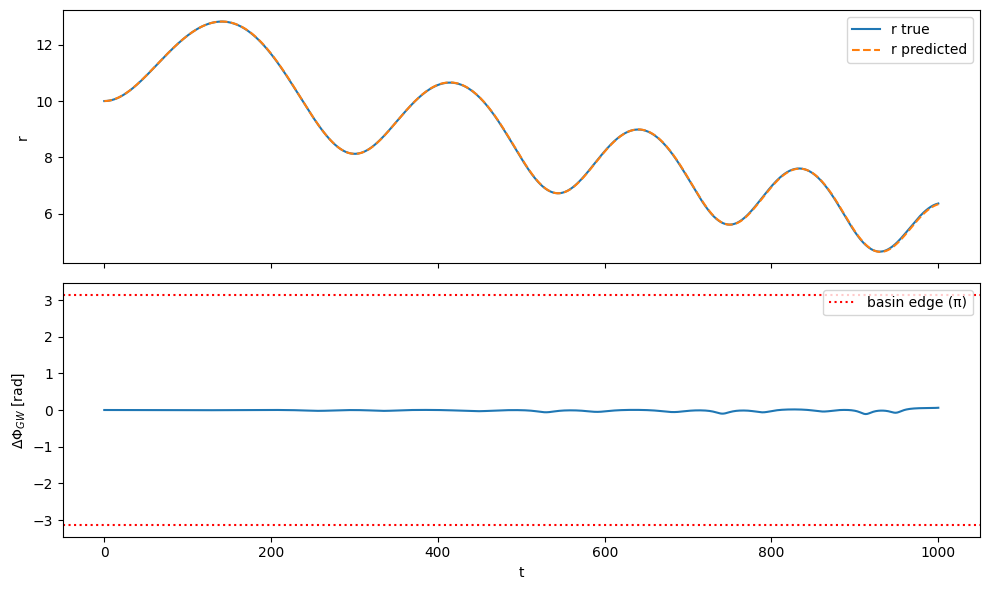


L_W read as a phase meter:  L_W = 2(1 - cos ΔΦ)
  random relative phase -> 2.000     exact antiphase -> 4.000
  exact Kerr               L_W= 6.653e-08  ->  ΔΦ ≈ 2.5793e-04 rad
  v9                       L_W= 3.450e-05  ->  ΔΦ ≈ 5.8737e-03 rad
  v10 θ_K                  L_W= 2.745e+00  ->  ΔΦ ≈ 1.9525e+00 rad  [SATURATED - no usable gradient]

USABLE-WINDOW SCAN  (integrate once, score on prefixes)
  t_final      N          L_W    ΔΦ [rad]  status
       19     20   2.0450e-06      0.0014  INFORMATIVE
       49     50   3.7242e-06      0.0019  INFORMATIVE
       99    100   7.7634e-06      0.0028  INFORMATIVE
      199    200   2.4021e-05      0.0049  INFORMATIVE
      349    350   1.4188e-04      0.0119  INFORMATIVE
      499    500   2.3363e-04      0.0153  INFORMATIVE
      750    750   8.1304e-04      0.0285  INFORMATIVE
     1000   1000   1.3314e-03      0.0365  INFORMATIVE

  longest window still informative at this metric accuracy: t = 1000
  -> start the v11 curriculum at or b

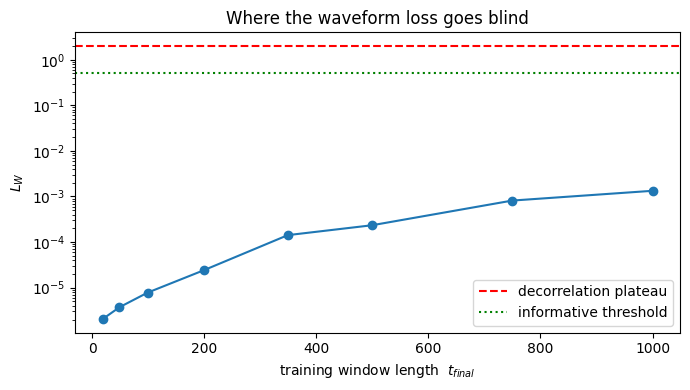

[(19.019018173217773, 20, 2.0449623679587798e-06, 0.0014300219286345853),
 (49.049049377441406, 50, 3.7241716767880134e-06, 0.001929811605471015),
 (99.0990982055664, 100, 7.763406539169038e-06, 0.0027862899277947477),
 (199.19920349121094, 200, 2.402127005624106e-05, 0.0049011547763212655),
 (349.3493347167969, 350, 0.00014188125274997346, 0.01191146213971843),
 (499.49951171875, 500, 0.00023362725721560228, 0.015285019000052073),
 (749.749755859375, 750, 0.0008130354098596902, 0.028514741825591165),
 (1000.0, 1000, 0.0013313720464167157, 0.036489995687461085)]

In [ ]:
dephasing_decomposition(net, stride=50)
phase_meter([("exact Kerr", 6.653e-8), ("v9", 3.45e-5), ("v10 θ_K", 2.745)])
usable_window_scan(net)


Phase diagnostic: observer 0, θ=0.000
RMS Δφ = 2.2610e-02 rad
Final Δφ = 6.6191e-02 rad
Final cycle error = 1.0535e-02


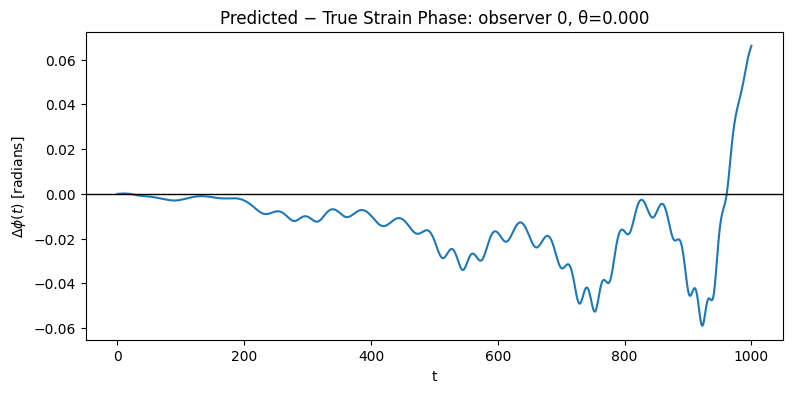


Phase diagnostic: observer 1, θ=0.785
RMS Δφ = 2.9057e-02 rad
Final Δφ = 4.1037e-02 rad
Final cycle error = 6.5312e-03


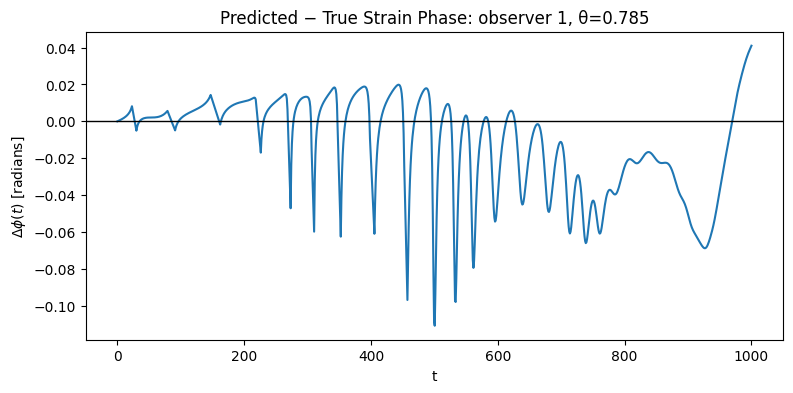

In [ ]:
phase_errors = []

for i, θ_obs in enumerate(θ_observed):
    hp_pred, hc_pred = create_gravityWave(
        t_test,
        traj,
        a_true,
        θ_obs=θ_obs,
        ϕ_obs=0.0
    )

    phase_errors.append(
        plot_phase_error(
            t_test,
            hp_pred,
            hc_pred,
            h_plus_true[i],
            h_cross_true[i],
            label=f"observer {i}, θ={θ_obs:.3f}"
        )
    )

In [ ]:
def vector_field_diagnostic(
    network,
    stride=10,
    eps=1e-12
):
    ref = next(network.parameters())

    # Evaluate both laws at identical points on exact Kerr trajectory
    states = trajectory_gate[::stride].to(
        dtype=ref.dtype,
        device=ref.device
    )

    # Parameters treated as fixed diagnostic constants
    params_dict = {
        name: parameter.detach()
        for name, parameter in network.named_parameters()
    }

    predicted_flow = []
    true_flow = []

    for state in states:
        predicted_flow.append(
            H_function(
                state,
                network,
                params_dict
            ).detach()
        )

        true_flow.append(
            H_Kerr(state).detach()
        )

    predicted_flow = torch.stack(predicted_flow)
    true_flow = torch.stack(true_flow)

    # Exclude dt/dt=1 and dp_t/dt=0
    indices = [1, 2, 3, 5, 6, 7]
    labels = [
        "dr/dt",
        "dθ/dt",
        "dφ/dt",
        "dp_r/dt",
        "dp_θ/dt",
        "dp_φ/dt"
    ]

    pred = predicted_flow[:, indices]
    true = true_flow[:, indices]
    difference = pred - true

    # RMS size of each exact component
    scales = torch.sqrt(
        true.square().mean(dim=0)
    ).clamp_min(eps)

    component_errors = (
        100
        * torch.sqrt(difference.square().mean(dim=0))
        / scales
    )

    # Equal weight for each normalized flow component
    normalized_difference = difference / scales

    combined_error = (
        100
        * torch.sqrt(
            normalized_difference.square().mean()
        )
    )

    error_vs_time = (
        100
        * torch.sqrt(
            normalized_difference.square().mean(dim=1)
        )
    )

    table = PrettyTable()
    table.field_names = [
        "Flow component",
        "Relative L2 error (%)"
    ]

    for label, error in zip(labels, component_errors):
        table.add_row([label, error.item()])

    table.float_format = ".4"

    print("\nHamiltonian/forward-flow diagnostic")
    print(f"Combined normalized error: {combined_error.item():.4f}%")
    print(table)

    plt.figure(figsize=(9, 4))
    plt.plot(
        states[:, 0].detach().cpu(),
        error_vs_time.detach().cpu()
    )
    plt.xlabel("t")
    plt.ylabel("Local flow error (%)")
    plt.title("Predicted vs. Kerr Dynamical Vector Field")
    plt.show()

    return component_errors, combined_error


Hamiltonian/forward-flow diagnostic
Combined normalized error: 0.4646%
+----------------+-----------------------+
| Flow component | Relative L2 error (%) |
+----------------+-----------------------+
|     dr/dt      |         0.0132        |
|     dθ/dt      |         0.0110        |
|     dφ/dt      |         0.0087        |
|    dp_r/dt     |         1.1227        |
|    dp_θ/dt     |         0.1846        |
|    dp_φ/dt     |         0.0084        |
+----------------+-----------------------+


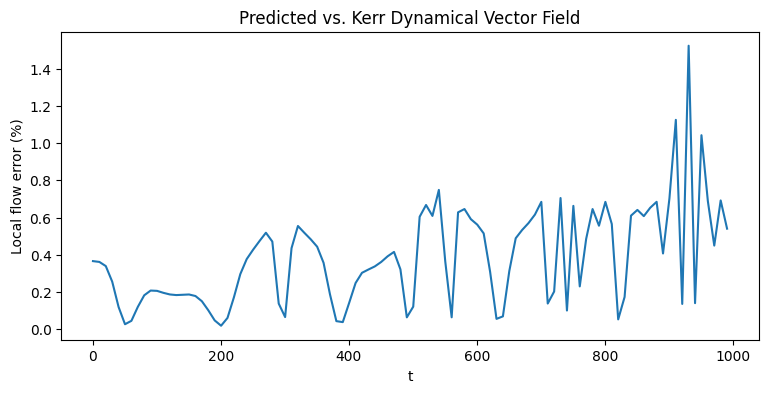

In [ ]:
flow_component_errors, flow_total_error = (
    vector_field_diagnostic(
        net,
        stride=10
    )
)

In [ ]:
# =============================================================================
#  Sonar v10/v11 diagnostics
#  Drop-in cells for Sonar_v10.ipynb. Uses only functions already defined in
#  the notebook: Kerr, g_Kerr, metric_from_network, integrate, create_gravityWave,
#  solve_ELQ, make_u0, Ricci, loss, net, t_test/t_full, hp_full/hc_full,
#  a_true, rp_true, ra_true, θmin_true, θ_observed, π
# =============================================================================


# =============================================================================
# CELL A — Generic forward harness   [place immediately AFTER cell 47]
# -----------------------------------------------------------------------------
# H_Kerr hardcodes Kerr(q, a=a_true) and H_function hardcodes the network.
# This is the same flow with the metric as an argument, so any metric --
# exact Kerr, perturbed Kerr, learned -- goes through one identical pipeline.
# =============================================================================

def H_generic(state, g_of_x):
  """Byte-for-byte H_Kerr, with a pluggable metric g_of_x(x4) -> (4,4)."""
  def H(state):
    q = state[:4]
    p = state[4:]
    g = g_of_x(q)
    inv_g = torch.linalg.inv(g)
    return 0.5 * p @ inv_g @ p

  grad_H = torch.func.grad(H)(state)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4, 4)
  J = torch.cat([torch.cat([Z4, I4], 1),
                 torch.cat([-I4, Z4], 1)])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative
  dτ_dt = (grad_H[4]) ** (-1)

  du = du_dτ * dτ_dt
  du[0] = 1
  return du


def g_kerr_fn(x):
  return Kerr(x, a=a_true)


def g_net_fn(network, params_dict=None):
  return lambda x: metric_from_network(network, x[1], x[2],
                                       params_dict=params_dict)


def solve_EL_from_metric(g_of_x, rp, ra, θmin, guess=None):
  """
  (E, L_z) such that r_p and r_a are radial turning points of THIS metric,
  with p_r = p_θ = 0 at θ = θmin -- i.e. the same initial-data structure
  make_u0 imposes, but consistent with the metric actually being integrated.

  Conditions: H(r_p, θmin, p_r=p_θ=0) = H(r_a, θmin, p_r=p_θ=0) = -1/2.
  Works for any stationary axisymmetric metric; no Carter constant needed.
  """
  from scipy import optimize

  def H_at(r, E, L):
    x = torch.tensor([0.0, r, θmin, 0.0], dtype=torch.get_default_dtype())
    ginv = torch.linalg.inv(g_of_x(x))
    p = torch.tensor([-E, 0.0, 0.0, L], dtype=torch.get_default_dtype())
    return float(0.5 * p @ ginv @ p)

  def eqs(v):
    E, L = float(v[0]), float(v[1])
    return [H_at(rp, E, L) + 0.5, H_at(ra, E, L) + 0.5]

  if guess is None:
    E0, L0, _ = solve_ELQ(rp, ra, θmin)
    guess = [E0, L0]

  E, L = optimize.fsolve(eqs, guess, full_output=False)
  return float(E), float(L)


def make_u0_consistent(g_of_x, rp=None, ra=None, θmin=None):
  """make_u0, but with (E, L_z) solved from g_of_x instead of from exact Kerr."""
  rp = rp_true if rp is None else rp
  ra = ra_true if ra is None else ra
  θmin = θmin_true if θmin is None else θmin
  E, L = solve_EL_from_metric(g_of_x, rp, ra, θmin)
  return torch.tensor([0.0, rp, θmin, 0.0, -E, 0.0, 0.0, L],
                      dtype=torch.get_default_dtype())


def waveform_from_metric(g_of_x, t_grid=None, θ_obs_list=None,
                         consistent_ic=True, return_traj=False):
  """metric -> geodesic -> (h_plus, h_cross) for each observer."""
  t_grid = t_test if t_grid is None else t_grid
  θ_obs_list = θ_observed if θ_obs_list is None else θ_obs_list

  u0 = (make_u0_consistent(g_of_x) if consistent_ic
        else make_u0(rp_true, ra_true, θmin_true))

  traj = integrate(lambda tt, s: H_generic(s, g_of_x), u0, t_grid)

  hp, hc = [], []
  for θo in θ_obs_list:
    a_, b_ = create_gravityWave(t_grid, traj, a_true, θ_obs=θo, ϕ_obs=0.0)
    hp.append(a_.detach())
    hc.append(b_.detach())

  return (hp, hc, traj) if return_traj else (hp, hc)


def mass_shell_report(g_of_x, label=""):
  """H(u0) must equal -1/2 for a unit-mass timelike geodesic."""
  u0_naive = make_u0(rp_true, ra_true, θmin_true)
  x, p = u0_naive[:4], u0_naive[4:]
  H = float(0.5 * p @ torch.linalg.inv(g_of_x(x)) @ p)
  print(f"{label:>24s} | H(u0_KerrIC) = {H:+.9f} | "
        f"mu^2_eff = {-2*H:.9f} | violation = {abs(-2*H - 1):.3e}")
  return H


# =============================================================================
# CELL B — Mismatch and dephasing   [place immediately AFTER Cell A]
# -----------------------------------------------------------------------------
# Relative L2 saturates near 141% for uncorrelated signals, so "165%" carries
# almost no information. These are the two numbers the GW literature uses.
# =============================================================================

def mismatch(hp1, hc1, hp2, hc2):
  """
  1 - max over time shift and overall phase of the normalized overlap,
  with a flat noise spectrum. 0 = identical, 1 = orthogonal.
  """
  z1 = torch.complex(hp1.detach().double(), hc1.detach().double())
  z2 = torch.complex(hp2.detach().double(), hc2.detach().double())

  n1 = torch.linalg.vector_norm(z1)
  n2 = torch.linalg.vector_norm(z2)

  n = 2 * z1.numel()

  corr = torch.fft.ifft(
      torch.fft.fft(z1, n=n)
      * torch.conj(torch.fft.fft(z2, n=n))
  )

  match = (
      n * corr.abs().max()
      / (n1 * n2 + 1e-300)
  ).clamp(0.0, 1.0)

  return float(1.0 - match)

def dephasing(hp1, hc1, hp2, hc2, amp_floor=0.05):
  """
  Accumulated GW phase difference in radians, zeroed at t=0.
  Samples where either amplitude drops below amp_floor * its RMS are masked,
  because the phase of a near-zero strain is numerically meaningless.
  """
  z1 = (hp1.detach().numpy() + 1j * hc1.detach().numpy())
  z2 = (hp2.detach().numpy() + 1j * hc2.detach().numpy())
  φ1 = np.unwrap(np.angle(z1))
  φ2 = np.unwrap(np.angle(z2))
  dφ = φ1 - φ2

  ok = (
      (np.abs(z1) > amp_floor * np.sqrt((np.abs(z1)**2).mean()))
      & (np.abs(z2) > amp_floor * np.sqrt((np.abs(z2)**2).mean()))
  )

  if ok.any():
      first = np.flatnonzero(ok)[0]
      dφ -= dφ[first]
  return dφ, ok


def _L_W(hp, hc, hp_ref, hc_ref):
  """Same normalization as waveform_loss / normalized_waveform_loss_from_arrays."""
  terms = []
  for pp, pc, tp, tc in zip(hp, hc, hp_ref, hc_ref):
    terms.append(((pp - tp).square() + (pc - tc).square()).mean()
                 / ((tp.square() + tc.square()).mean() + 1e-12))
  return float(torch.stack(terms).mean())


def waveform_report(hp, hc, hp_ref=None, hc_ref=None, label=""):
  hp_ref = hp_full if hp_ref is None else hp_ref
  hc_ref = hc_full if hc_ref is None else hc_ref
  MM, DP = [], []
  for i in range(len(hp)):
    MM.append(mismatch(hp[i], hc[i], hp_ref[i], hc_ref[i]))
    dφ, ok = dephasing(hp[i], hc[i], hp_ref[i], hc_ref[i])
    DP.append(np.abs(dφ[ok]).max() if ok.any() else np.nan)
  L2 = _L_W(hp, hc, hp_ref, hc_ref)
  print(f"{label:>26s} | L_W = {L2:.4e} | mismatch = {np.mean(MM):.4e} "
        f"| max|dPhi| = {np.max(DP):7.3f} rad")
  return dict(L_W=L2, mismatch=float(np.mean(MM)), dphi_max=float(np.max(DP)))


# =============================================================================
# CELL C — THE SANITY CHECK: per-component waveform sensitivity
#          [place AFTER Cell B; runs standalone, needs no trained network]
# -----------------------------------------------------------------------------
# Freeze exact Kerr. Perturb ONE component at a time by a controlled fractional
# amount. Propagate the identical orbit and observer projection. This answers:
# how accurate does each metric component have to be before v11 has a chance?
#
# mode="value" : g_c -> g_c * (1 + eps)                  (offset, slope scales too)
# mode="grad"  : g_c -> g_c * (1 + eps*(r-r0)/r0)        (ZERO at r0, pure slope)
#
# The pair separates "does the waveform care about g" from "does it care about
# dg/dr". Run both; compare the sensitivity columns.
# =============================================================================

COMPONENT_SLOTS = {
    "g_tt":  [(0, 0)],
    "g_rr":  [(1, 1)],
    "g_thth": [(2, 2)],
    "g_phph": [(3, 3)],
    "g_tph": [(0, 3), (3, 0)],   # both, to preserve symmetry
}


def perturbed_kerr_fn(component, eps, mode="value", r0=12.0):
  slots = COMPONENT_SLOTS[component]

  def g(x):
    base = Kerr(x, a=a_true)
    r = x[1]
    factor = (1.0 + eps) if mode == "value" else (1.0 + eps * (r - r0) / r0)
    mask = torch.zeros_like(base)
    for (i, j) in slots:
      mask[i, j] = 1.0
    return base * (1.0 - mask) + base * mask * factor

  return g


def component_sensitivity_sweep(eps_list=(1e-4, 1e-3, 1e-2),
                                modes=("value", "grad"),
                                components=tuple(COMPONENT_SLOTS),
                                r0=12.0, consistent_ic=False):
  """
  ~8 s per row. Default grid = 5 components x 3 eps x 2 modes = 30 rows.
  consistent_ic=False keeps the exact-Kerr (E, L_z) so the perturbation is the
  ONLY thing that changes -- that is what you want for a sensitivity derivative.
  """
  hp0, hc0 = waveform_from_metric(g_kerr_fn, consistent_ic=consistent_ic)

  tab = PrettyTable()
  tab.title = "Waveform sensitivity to single-component metric perturbations"
  tab.field_names = ["component", "mode", "eps", "mismatch",
                     "max|dPhi| (rad)", "dPhi/eps", "eps for 1 rad"]
  tab.float_format = ".3"
  rows = []

  for mode in modes:
    for comp in components:
      for eps in eps_list:
        hp, hc = waveform_from_metric(
            perturbed_kerr_fn(comp, eps, mode=mode, r0=r0),
            consistent_ic=consistent_ic)
        mm = np.mean([mismatch(hp[i], hc[i], hp0[i], hc0[i])
                      for i in range(len(hp))])
        dφ, ok = dephasing(hp[0], hc[0], hp0[0], hc0[0])
        dmax = np.abs(dφ[ok]).max() if ok.any() else np.nan
        slope = dmax / eps
        tab.add_row([comp, mode, f"{eps:.0e}", f"{mm:.3e}",
                     f"{dmax:.4f}", f"{slope:.3e}",
                     f"{1.0/slope:.2e}" if slope > 0 else "inf"])
        rows.append(dict(component=comp, mode=mode, eps=eps,
                         mismatch=float(mm), dphi_max=float(dmax),
                         slope=float(slope)))
      tab.add_row(["-" * 8] * 7)

  print(tab)
  print("\n'eps for 1 rad' = fractional accuracy this component needs before")
  print("dephasing alone destroys the waveform over the training window.")
  print("Compare across components: L_K weights all five EQUALLY.")
  return tab, rows


# =============================================================================
# CELL D — Physical sign condition on g_tt
#          [place after cell 105, next to print_metric_error_table]
# -----------------------------------------------------------------------------
# Kerr: g_tt(r,θ) - g_tt(r,π/2) = -2Ma^2cos^2θ / [r(r^2+a^2cos^2θ)] <= 0, strictly.
# Any learned metric violating this is unphysical regardless of its L2 error.
# =============================================================================

def gtt_sign_check(network, r_grid=(2, 3, 4, 5, 6, 8, 10, 12, 14, 20),
                   θ_grid=(π/20, π/4, π/3), verbose=True):
  ref = next(network.parameters())
  T = lambda v: torch.tensor(v, dtype=ref.dtype, device=ref.device)

  tab = PrettyTable()
  tab.title = "g_tt(r,θ) - g_tt(r,π/2)   [Kerr requires < 0 everywhere]"
  tab.field_names = ["r", "θ", "Kerr Δ", "learned Δ", "sign",
                     "|Kerr Δ|", "fit residual", "signal/residual"]
  n_bad = 0

  with torch.no_grad():
    for r in r_grid:
      for θ in θ_grid:
        rt, θt, eqt = T(float(r)), T(float(θ)), T(π/2)
        dk = float(g_Kerr(rt, θt)[0, 0] - g_Kerr(rt, eqt)[0, 0])
        dn = float(metric_from_network(network, rt, θt)[0, 0]
                   - metric_from_network(network, rt, eqt)[0, 0])
        res = abs(float(metric_from_network(network, rt, θt)[0, 0]
                        - g_Kerr(rt, θt)[0, 0]))
        bad = dn >= 0
        n_bad += bad
        tab.add_row([f"{r:g}", f"{θ/π:.3f}π", f"{dk:.3e}", f"{dn:.3e}",
                     "VIOLATED" if bad else "ok", f"{abs(dk):.3e}",
                     f"{res:.3e}", f"{abs(dk)/max(res,1e-30):.2f}"])
      tab.add_row(["-"*5]*8)

  if verbose:
    print(tab)
    print(f"\nviolations: {n_bad} / {len(r_grid)*len(θ_grid)}")
    print("signal/residual < 1  =>  the loss cannot see the polar structure")
    print("of g_tt at that radius, so its sign is unconstrained.")
  return tab, n_bad


# =============================================================================
# CELL E — Exact horizon diagnostics
#          [place after cell 75, replacing reliance on the softmax proxy]
# -----------------------------------------------------------------------------
# boundaryConditionLoss uses a softmax-weighted mean of 10 radii in [1, 2.01].
# That is fine as a differentiable TRAINING term and bad as a DIAGNOSTIC.
# This does a real bracketed root solve and then checks the horizon physics.
# =============================================================================

def horizon_report(g_of_x, θ_grid=(π/20, π/4, π/3, π/2),
                   r_lo=1.02, r_hi=2.5, n_bisect=80):
  r_plus = 1.0 + math.sqrt(1.0 - a_true ** 2)
  Ω_H = a_true / (2.0 * 1.0 * r_plus)

  def grr_inv(r, θ):
    x = torch.tensor([0.0, r, θ, 0.0], dtype=torch.get_default_dtype())
    return float(1.0 / g_of_x(x)[1, 1])

  tab = PrettyTable()
  tab.title = (f"Horizon diagnostics   [Kerr: r+ = {r_plus:.6f}, "
               f"Omega_H = {Ω_H:.6f}, theta-independent]")
  tab.field_names = ["θ", "r_H", "err r_H", "omega(r_H)", "err omega",
                     "chi^2 @ true Omega_H"]
  roots = []

  with torch.no_grad():
    for θ in θ_grid:
      lo, hi = r_lo, r_hi
      f_lo = grr_inv(lo, θ)
      if f_lo * grr_inv(hi, θ) > 0:
        tab.add_row([f"{θ/π:.3f}π", "no root", "-", "-", "-", "-"])
        continue
      for _ in range(n_bisect):
        mid = 0.5 * (lo + hi)
        if f_lo * grr_inv(mid, θ) <= 0:
          hi = mid
        else:
          lo, f_lo = mid, grr_inv(mid, θ)
      rH = 0.5 * (lo + hi)
      roots.append(rH)

      g = g_of_x(torch.tensor([0.0, rH, θ, 0.0],
                              dtype=torch.get_default_dtype()))
      ω = float(-g[0, 3] / g[3, 3])
      χ2 = float(g[0, 0] + 2 * Ω_H * g[0, 3] + Ω_H ** 2 * g[3, 3])
      tab.add_row([f"{θ/π:.3f}π", f"{rH:.6f}",
                   f"{100*(rH-r_plus)/r_plus:+.2f}%", f"{ω:.6f}",
                   f"{100*(ω-Ω_H)/Ω_H:+.2f}%", f"{χ2:+.4e}"])

  print(tab)
  if roots:
    print(f"\nhorizon theta-spread: {100*(max(roots)-min(roots))/np.mean(roots):.2f}% "
          f"(Kerr = 0.00% exactly)")
    print("chi^2 != 0 at the true Omega_H means the surface is not a Killing horizon.")
  return roots


def frame_dragging_report(g_of_x, r_grid=(3, 6, 10, 14, 20, 50),
                          θ=π/2):
  """omega = -g_tphi/g_phiphi and J_eff = -r g_tphi / (2 sin^2 θ) -> aM = 0.9."""
  tab = PrettyTable()
  tab.title = f"Frame dragging at theta = {θ/π:.2f}pi   [J_eff -> aM = {a_true:.3f}]"
  tab.field_names = ["r", "omega (learned)", "omega (Kerr)", "J_eff", "err J_eff"]
  with torch.no_grad():
    for r in r_grid:
      x = torch.tensor([0.0, float(r), θ, 0.0], dtype=torch.get_default_dtype())
      g, gk = g_of_x(x), Kerr(x, a=a_true)
      ω = float(-g[0, 3] / g[3, 3])
      ωk = float(-gk[0, 3] / gk[3, 3])
      J = float(-r * g[0, 3] / (2 * math.sin(θ) ** 2))
      tab.add_row([f"{r:g}", f"{ω:.6e}", f"{ωk:.6e}", f"{J:.6f}",
                   f"{100*(J-a_true)/a_true:+.2f}%"])
  print(tab)


# =============================================================================
# CELL F — Gauss-Newton vs full Hessian
#          [place immediately AFTER cell 95, supervised_hessian_spectrum]
# -----------------------------------------------------------------------------
# L_K is a weighted sum of squares, so H = 2 J^T W J  +  2 sum(w rho grad^2 rho).
# The first term is PSD by construction. Splitting them tells you whether the
# negative eigenvalues are real curvature or just the residual term acting in
# the Gauss-Newton null space -- which changes the interpretation completely.
# =============================================================================

def gauss_newton_split(network, plot=True):
  ref = next(network.parameters())
  names = [n for n, _ in network.named_parameters()]
  x0 = torch.nn.utils.parameters_to_vector(network.parameters()).detach().clone()

  radial_vals = torch.logspace(math.log10(2), math.log10(20), 10,
                               dtype=ref.dtype, device=ref.device)
  angular_vals = torch.linspace(π/20, π/2, 6, dtype=ref.dtype, device=ref.device)
  idx = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]

  # sqrt-weighted residual vector, exactly the quantity L_K sums the square of
  true_prof = []
  for r in radial_vals:
    for θ in angular_vals:
      t = g_Kerr(r, θ)
      true_prof.append(torch.stack([t[μ, ν] for μ, ν in idx]))
  true_prof = torch.stack(true_prof).reshape(10, 6, 5)
  den = (true_prof ** 2).sum(dim=1)                      # (10,5)
  w = 1.0 / (50.0 * (den + 1e-12))
  sw = torch.sqrt(w).unsqueeze(1).expand(10, 6, 5).reshape(-1)

  def resid_from_vector(flat):
    shapes = [p.shape for p in network.parameters()]
    numels = [p.numel() for p in network.parameters()]
    parts, o = [], 0
    for s, n in zip(shapes, numels):
      parts.append(flat[o:o+n].reshape(s)); o += n
    pd = dict(zip(names, parts))
    pred = []
    for r in radial_vals:
      for θ in angular_vals:
        g = metric_from_network(network, r, θ, params_dict=pd)
        pred.append(torch.stack([g[μ, ν] for μ, ν in idx]))
    pred = torch.stack(pred).reshape(10, 6, 5)
    return sw * (pred - true_prof).reshape(-1)

  J = torch.autograd.functional.jacobian(resid_from_vector, x0, vectorize=True)
  GN = 2.0 * (J.T @ J)
  GN = 0.5 * (GN + GN.T)
  gn_ev = torch.linalg.eigvalsh(GN).detach()

  def scalar_loss(flat):
    return (resid_from_vector(flat) ** 2).sum()

  H = torch.autograd.functional.hessian(scalar_loss, x0, vectorize=True)
  H = 0.5 * (H + H.T)
  ev = torch.linalg.eigvalsh(H).detach()

  lam_max = float(ev.abs().max())
  neg = ev[ev < -1e-10 * lam_max]

  print("\nGauss-Newton vs full Hessian of L_K")
  print(f"  parameters                        : {H.shape[0]}")
  print(f"  lambda_max  (full H)              : {float(ev[-1]):.6e}")
  print(f"  lambda_max  (Gauss-Newton, PSD)   : {float(gn_ev[-1]):.6e}")
  print(f"  lambda_min  (full H)              : {float(ev[0]):.6e}")
  print(f"  |lambda_min| / lambda_max         : {abs(float(ev[0]))/float(ev[-1]):.3e}")
  print(f"  negative directions               : {len(neg)}")
  print(f"  GN directions above 1e-10*max     : "
        f"{int((gn_ev > 1e-10*float(gn_ev[-1])).sum())} / {H.shape[0]}")
  for tol in [1e-2, 1e-4, 1e-6, 1e-8]:
    print(f"  GN eigenvalues > {tol:>6.0e}*lambda_max : "
          f"{int((gn_ev > tol*float(gn_ev[-1])).sum()):3d}")
  pr = float(gn_ev.sum() ** 2 / (gn_ev ** 2).sum())
  print(f"  participation ratio               : {pr:.2f} effective directions")
  print("\n  If |lambda_min|/lambda_max << 1 and the negatives sit inside the GN")
  print("  null space, this is a flat plateau of an overparameterized model,")
  print("  NOT a saddle the optimizer is stuck on.")

  if plot:
    pos = ev[ev > 1e-14 * lam_max]
    plt.figure(figsize=(7, 4))
    plt.semilogy(pos.flip(0).cpu(), "o-", label="full Hessian (positive)")
    gpos = gn_ev[gn_ev > 1e-14 * float(gn_ev[-1])]
    plt.semilogy(gpos.flip(0).cpu(), "s--", label="Gauss-Newton (PSD)")
    plt.xlabel("eigenvalue rank (sorted descending -- the decrease is the SORT)")
    plt.ylabel("eigenvalue")
    plt.title("L_K curvature spectrum")
    plt.legend(); plt.tight_layout(); plt.show()

  return ev, gn_ev, H, GN


# =============================================================================
# CELL G — Waveform Fisher, and cross-projection against the L_K null space
#          [place AFTER Cell F. This is the identifiability diagnostic.]
# -----------------------------------------------------------------------------
# The L_K Hessian lives in WEIGHT space. Its sloppy directions say "many weight
# vectors give the same metric" -- a statement about the MLP, not about GR.
# The question that matters is: do those directions change the WAVEFORM?
#   ||J_wave v|| large  -> the waveform sees what L_K cannot. Train on waveforms.
#   ||J_wave v|| small  -> genuine physical degeneracy. That is the paper.
# =============================================================================

def directional_waveform_sensitivity(network, H_LK, k_flat=6, k_stiff=3,
                                     eps=1e-3, consistent_ic=False):
  """
  Take the eigenvectors of the L_K Hessian and ask, for each one, how much the
  WAVEFORM moves along it. One waveform evaluation per direction (~8 s).

    high  ||dh||/||h|| on a FLAT L_K direction
        -> the waveform constrains something the metric loss cannot see.
           Waveform training adds real information. Good for v11.
    low   ||dh||/||h|| on a FLAT L_K direction
        -> a genuine physical degeneracy: a metric deformation no EMRI
           waveform in this configuration can constrain. That is the result.
  """
  ref = next(network.parameters())
  x0 = torch.nn.utils.parameters_to_vector(network.parameters()).detach().clone()

  evals, evecs = torch.linalg.eigh(0.5 * (H_LK + H_LK.T))
  order_flat = torch.argsort(evals.abs())          # flattest first
  picks = ([("flat", int(order_flat[j])) for j in range(k_flat)] +
           [("stiff", int(i)) for i in range(len(evals) - k_stiff, len(evals))])

  def strain_at(vec):
    torch.nn.utils.vector_to_parameters(vec.to(ref.dtype), network.parameters())
    pd = dict(network.named_parameters())
    hp, hc = waveform_from_metric(g_net_fn(network, pd),
                                  consistent_ic=consistent_ic)
    flat = torch.cat([torch.cat([a.flatten(), b.flatten()])
                      for a, b in zip(hp, hc)]).detach()
    return flat, hp, hc

  base, hp0, hc0 = strain_at(x0)
  LK0 = float(loss(network)[0].detach())
  norm_h = float(torch.linalg.vector_norm(base))

  tab = PrettyTable()
  tab.title = "Does the waveform see the directions L_K is blind to?"
  tab.field_names = ["kind", "lambda(L_K)", "dL_K", "||dh||/||h||/eps",
                     "mismatch", "info ratio", "verdict"]
  rows = []

  for kind, idx in picks:
    v = evecs[:, idx] / torch.linalg.vector_norm(evecs[:, idx])
    pert, hp, hc = strain_at(x0 + eps * v.to(x0.dtype))
    LK1 = float(loss(network)[0].detach())
    dLK = LK1 - LK0

    resp = float(torch.linalg.vector_norm(pert - base)) / (norm_h * eps)
    mm = float(np.mean([mismatch(hp[i], hc[i], hp0[i], hc0[i])
                        for i in range(len(hp))]))

    # waveform information per unit metric-loss information along this direction
    ratio = (resp * eps) ** 2 / max(abs(dLK), 1e-300)
    verdict = ("waveform SEES it" if (kind == "flat" and resp > 1e-2)
               else "degenerate in BOTH" if kind == "flat"
               else "-")
    tab.add_row([kind, f"{float(evals[idx]):+.3e}", f"{dLK:+.2e}",
                 f"{resp:.4e}", f"{mm:.3e}", f"{ratio:.2e}", verdict])
    rows.append(dict(kind=kind, lam=float(evals[idx]), resp=resp,
                     mm=mm, ratio=ratio))

  torch.nn.utils.vector_to_parameters(x0.to(ref.dtype), network.parameters())
  print(tab)
  print("\n'info ratio' = (relative waveform change)^2 / (change in L_K).")
  print("It is how much observational information a direction carries per unit")
  print("of supervised-loss signal. If the FLAT rows have a far larger ratio")
  print("than the STIFF rows, L_K is the wrong objective: the waveform carries")
  print("information in exactly the directions the metric fit cannot see.")
  print("\nNOTE: this is a WEIGHT-space basis. For a publishable identifiability")
  print("claim, repeat in a PHYSICAL basis -- e.g. deformation coefficients of")
  print("m(r) and q(r) in a Kerr-shaped ansatz -- so each null direction reads as")
  print("'the waveform cannot distinguish this mass profile from that one'.")
  return tab, rows


# =============================================================================
# CELL H — v9 vs v10 head-to-head   [place after cell 106]
# -----------------------------------------------------------------------------
# The one-cell experiment. You have both checkpoints.
#   v9 worse componentwise but better L_W  -> degeneracy. THE result.
#   v9 better on both                      -> drop supervised metric loss.
# =============================================================================

def compare_checkpoints(paths):
  """paths: {"v10 supervised": "/content/sonar_v10_0.pt", "v9 inverse": "..."}"""
  ref_dtype = next(net.parameters()).dtype
  saved = torch.nn.utils.parameters_to_vector(net.parameters()).detach().clone()
  out = {}

  hp_k, hc_k = waveform_from_metric(g_kerr_fn, consistent_ic=False)
  waveform_report(hp_k, hc_k, label="exact Kerr (floor)")

  for label, path in paths.items():
    sd = torch.load(path, map_location="cpu")
    sd = sd.get("net_state", sd)
    net.load_state_dict({k: v.to(ref_dtype) for k, v in sd.items()})

    L_K, comp = loss(net)
    print(f"\n===== {label} =====")
    print(f"L_K = {float(L_K):.4e}   E_total = {100*math.sqrt(float(L_K)):.3f}%")
    print("  componentwise %:", [f"{100*math.sqrt(float(c)):.3f}" for c in comp])

    pd = dict(net.named_parameters())
    hp, hc = waveform_from_metric(g_net_fn(net, pd), consistent_ic=False)
    res = waveform_report(hp, hc, label=label)
    _, n_bad = gtt_sign_check(net, verbose=False)
    print(f"  g_tt sign violations: {n_bad}")
    horizon_report(g_net_fn(net, pd))
    out[label] = dict(L_K=float(L_K), n_bad=int(n_bad), **res)

  torch.nn.utils.vector_to_parameters(saved.to(ref_dtype), net.parameters())
  return out


# =============================================================================
# CELL I — two one-line fixes
# =============================================================================
#
# (1) cell 90, run_bfgs_stage: BFGS exited at iteration 0 because you passed
#     gtol=1e-4 while the handoff gradient was 6.681e-06. SciPy tests
#     max|g_i| <= gtol BEFORE the first step.
#
#         options={
#             "maxiter": maxiter,
#             "gtol": 1e-12,          # was 1e-4
#             "xrtol": 1e-14,
#             "method_bfgs": "SSBroyden2",
#             "initial_scale": False,
#             "disp": True,
#         },
#
# (2) cell 44, waveform_loss: make_u0 always uses a=a_true, so (E, L_z, Q) are
#     exact-Kerr values evolved under the LEARNED Hamiltonian. r_p and r_a are
#     then not turning points of the metric being tested -- you are comparing
#     different orbits, not different metrics.
#
#         u0 = make_u0_consistent(g_net_fn(network, params_dict))
#
#     (add `from Cell A` above; keep the old line behind a flag so you can
#      measure how much of L_W the IC inconsistency was responsible for.)
# =============================================================================


# =============================================================================
# CELL J — run everything   [place at the very end of the notebook]
# =============================================================================

def run_all_diagnostics(network=None, sweep=True):
  network = net if network is None else network
  pd = dict(network.named_parameters())
  g_learned = g_net_fn(network, pd)

  print("\n" + "=" * 78 + "\n  MASS SHELL\n" + "=" * 78)
  mass_shell_report(g_kerr_fn, "exact Kerr")
  mass_shell_report(g_learned, "learned")

  print("\n" + "=" * 78 + "\n  WAVEFORM (mismatch + dephasing, not just L2)\n" + "=" * 78)
  hp_k, hc_k = waveform_from_metric(g_kerr_fn, consistent_ic=False)
  waveform_report(hp_k, hc_k, label="exact Kerr (floor)")
  hp_n, hc_n = waveform_from_metric(g_learned, consistent_ic=False)
  waveform_report(hp_n, hc_n, label="learned, Kerr IC")
  hp_c, hc_c = waveform_from_metric(g_learned, consistent_ic=True)
  waveform_report(hp_c, hc_c, label="learned, consistent IC")

  print("\n" + "=" * 78 + "\n  PHYSICAL SIGN CONDITION ON g_tt\n" + "=" * 78)
  gtt_sign_check(network)

  print("\n" + "=" * 78 + "\n  HORIZON + FRAME DRAGGING\n" + "=" * 78)
  horizon_report(g_learned)
  frame_dragging_report(g_learned)

  print("\n" + "=" * 78 + "\n  CURVATURE SPECTRUM\n" + "=" * 78)
  ev, gn_ev, H, GN = gauss_newton_split(network)

  print("\n" + "=" * 78 + "\n  IDENTIFIABILITY CROSS-PROJECTION\n" + "=" * 78)
  directional_waveform_sensitivity(network, H, k_flat=4, k_stiff=2)

  if sweep:
    print("\n" + "=" * 78 + "\n  SANITY CHECK: component sensitivity (~3 min)\n" + "=" * 78)
    component_sensitivity_sweep(eps_list=(1e-3, 1e-2))

  # dephasing curve -- the picture behind "phase trapping"
  dφ, ok = dephasing(hp_n[0], hc_n[0], hp_k[0], hc_k[0])
  plt.figure(figsize=(8, 4))
  plt.plot(t_test.detach()[ok], dφ[ok])
  plt.axhline(1.0, ls="--", c="k", lw=0.8)
  plt.axhline(-1.0, ls="--", c="k", lw=0.8)
  plt.xlabel("t [M]"); plt.ylabel(r"$\Delta\Phi_{\rm GW}$ [rad]")
  plt.title("Accumulated dephasing, learned vs exact Kerr  (|dPhi|=1 rad dashed)")
  plt.tight_layout(); plt.show()


  MASS SHELL
              exact Kerr | H(u0_KerrIC) = -0.500000000 | mu^2_eff = 1.000000001 | violation = 5.185e-10
                 learned | H(u0_KerrIC) = -0.500042429 | mu^2_eff = 1.000084858 | violation = 8.486e-05

  WAVEFORM (mismatch + dephasing, not just L2)
        exact Kerr (floor) | L_W = 6.7445e-09 | mismatch = 0.0000e+00 | max|dPhi| =   0.000 rad
          learned, Kerr IC | L_W = 1.3314e-03 | mismatch = 0.0000e+00 | max|dPhi| =   0.197 rad
    learned, consistent IC | L_W = 3.4951e-02 | mismatch = 0.0000e+00 | max|dPhi| =   0.456 rad

  PHYSICAL SIGN CONDITION ON g_tt
+--------------------------------------------------------------------------------------------------+
|                     g_tt(r,θ) - g_tt(r,π/2)   [Kerr requires < 0 everywhere]                     |
+-------+--------+------------+------------+----------+-----------+--------------+-----------------+
|   r   |   θ    |   Kerr Δ   | learned Δ  |   sign   |  |Kerr Δ| | fit residual | signal/residual |
+--

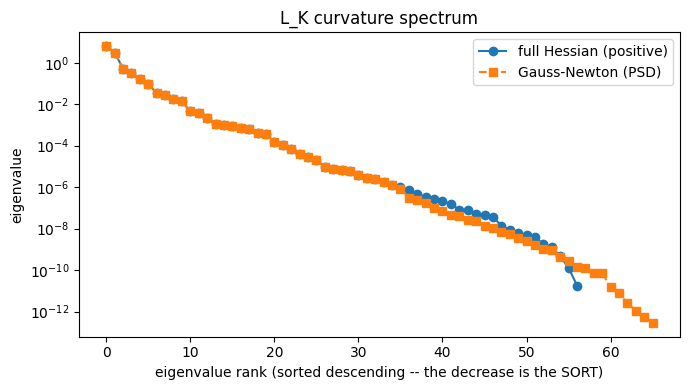


  IDENTIFIABILITY CROSS-PROJECTION
+--------------------------------------------------------------------------------------------------+
|                      Does the waveform see the directions L_K is blind to?                       |
+-------+-------------+-----------+------------------+-----------+------------+--------------------+
|  kind | lambda(L_K) |    dL_K   | ||dh||/||h||/eps |  mismatch | info ratio |      verdict       |
+-------+-------------+-----------+------------------+-----------+------------+--------------------+
|  flat |  -7.213e-12 | +8.60e-14 |    5.8395e-03    | 0.000e+00 |  3.97e+02  | degenerate in BOTH |
|  flat |  +1.785e-11 | -3.91e-14 |    5.5117e-03    | 0.000e+00 |  7.76e+02  | degenerate in BOTH |
|  flat |  +1.290e-10 | -8.89e-14 |    2.9939e-04    | 0.000e+00 |  1.01e+00  | degenerate in BOTH |
|  flat |  -1.433e-10 | -1.79e-13 |    9.5561e-03    | 0.000e+00 |  5.09e+02  | degenerate in BOTH |
| stiff |  +3.065e+00 | +1.54e-06 |    1.3776e+02    | 

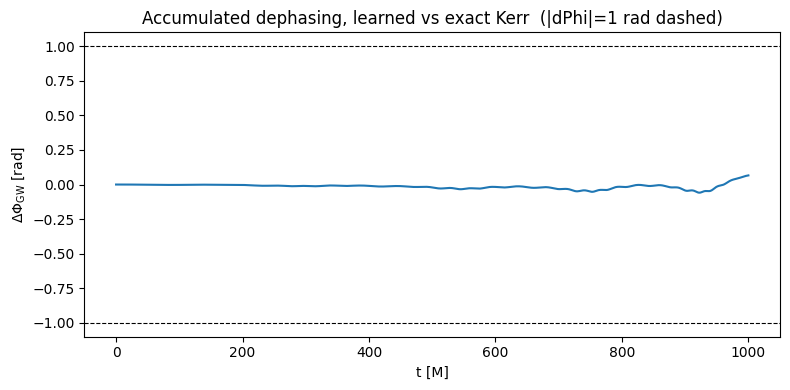

In [ ]:
run_all_diagnostics(sweep=False)

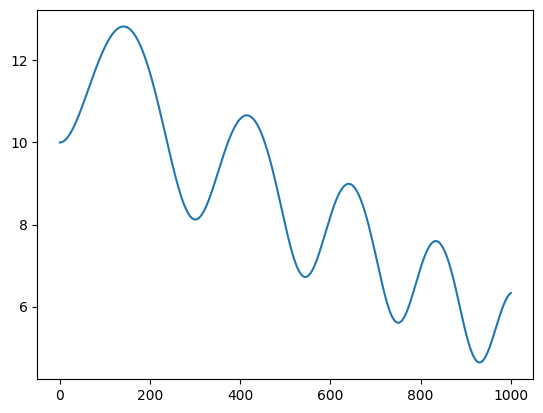

In [ ]:
plt.plot(t_test, traj[:,1].detach().numpy())

In [ ]:
physicality_report(net)
sobolev_error_table(net)


GATE 1  g_tt(r,θ) - g_tt(r,π/2) <= 0  for all θ   [Kerr identity]
      r       |      θ=0.16 |      θ=0.79 |      θ=1.05 |      θ=1.40
      2  pred | -1.650e-01 | -9.194e-02 | -4.817e-02 | -5.808e-03   ok
         true | -1.650e-01 | -9.194e-02 | -4.819e-02 | -5.816e-03
      3  pred | -5.393e-02 | -2.876e-02 | -1.497e-02 | -1.812e-03   ok
         true | -5.381e-02 | -2.871e-02 | -1.467e-02 | -1.729e-03
      5  pred | -1.256e-02 | -6.457e-03 | -3.399e-03 | -4.227e-04   ok
         true | -1.226e-02 | -6.377e-03 | -3.214e-03 | -3.740e-04
     10  pred | -1.547e-03 | -7.240e-04 | -4.075e-04 | -5.646e-05   ok
         true | -1.568e-03 | -8.067e-04 | -4.042e-04 | -4.679e-05
     14  pred | -3.973e-04 | -1.424e-04 | -9.637e-05 | -1.676e-05   ok
         true | -5.736e-04 | -2.946e-04 | -1.474e-04 | -1.705e-05
     20  pred | +4.961e-05 | +7.473e-05 | +2.354e-05 | -6.663e-07   FAIL
         true | -1.972e-04 | -1.011e-04 | -5.060e-05 | -5.850e-06
    100  pred | +1.149e-04 | +7.126e-05

[(3.0,
  0.06008948581395223,
  0.00872552351468131,
  0.32083973510211444,
  0.015183915584674768),
 (5.0,
  0.004666708518563656,
  0.057351151830382224,
  0.1250923079730657,
  0.029717279511927992),
 (8.0,
  0.0028949364431133753,
  0.012864604552920156,
  0.037512563757480244,
  0.0027145191221247347),
 (10.0,
  0.0032471723745985948,
  0.004727918810239207,
  0.018131796204030014,
  0.0008946518175632846),
 (12.0,
  0.003222024617710595,
  0.0005963095178640465,
  0.010470083955158721,
  0.0022579927967649894),
 (14.0,
  0.003109505785048316,
  0.0022856375275395746,
  0.006757607192989193,
  0.0031055868105488503),
 (20.0,
  0.0027070974901116035,
  0.008863398547817591,
  0.0007477656252660378,
  0.005361559547950734)]

Stride of 10 Elements Comparison:

Time: tensor([  0.0000,  10.0100,  20.0200,  30.0300,  40.0400,  50.0500,  60.0601,
         70.0701,  80.0801,  90.0901, 100.1001, 110.1101, 120.1201, 130.1301,
        140.1401, 150.1501, 160.1602, 170.1702, 180.1802, 190.1902, 200.2002,
        210.2102, 220.2202, 230.2302, 240.2402, 250.2502, 260.2603, 270.2703,
        280.2803, 290.2903, 300.3003, 310.3103, 320.3203, 330.3303, 340.3403,
        350.3503, 360.3604, 370.3704, 380.3804, 390.3904, 400.4004, 410.4104,
        420.4204, 430.4304, 440.4404, 450.4504, 460.4604, 470.4705, 480.4805,
        490.4905, 500.5005, 510.5105, 520.5205, 530.5305, 540.5405, 550.5505,
        560.5605, 570.5706, 580.5806, 590.5906, 600.6006, 610.6106, 620.6206,
        630.6306, 640.6406, 650.6506, 660.6606, 670.6707, 680.6807, 690.6907,
        700.7007, 710.7107, 720.7207, 730.7307, 740.7407, 750.7507, 760.7607,
        770.7708, 780.7808, 790.7908, 800.8008, 810.8108, 820.8208, 830.8308,
        840.8408, 850.8

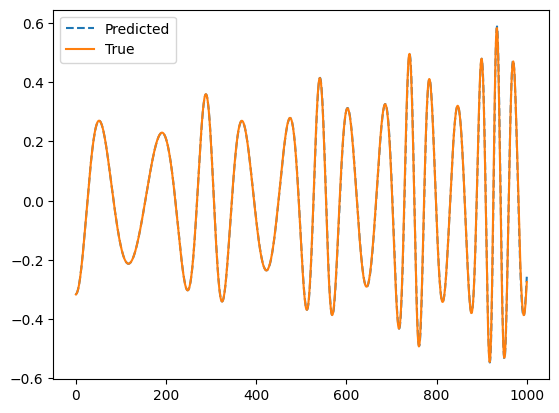

In [ ]:
t_final_plot = len(t_test)

plt.plot(t_test.detach()[0:t_final_plot], hp_trained.detach()[0:t_final_plot], label = "Predicted", linestyle='dashed')
plt.plot(t_test.detach()[0:t_final_plot], h_plus_true[0][0:t_final_plot], label = "True", linestyle = "solid")

print("Stride of 10 Elements Comparison:\n")
print("Time:", t_test.detach()[::10])
print("hp_trained.detach:", hp_trained.detach()[::10])
print("h_plus_true:", h_plus_true[0][::10])

plt.legend()

In [ ]:
from matplotlib.lines import Line2D

def compare_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, math.pi/20]

  # fig, axes = plt.subplots(2, 3)

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_by_component = []
  true_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T
    pred_by_component.append(pred_i)
    true_by_component.append(true_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    ax.set_title(f"${components[i]}$ Component")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    figs.append(fig)

  return figs, pred_by_component, true_by_component

def angular_comparison_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, 0]

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_diff_by_component = []
  true_diff_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T

    pred_diff_i = pred_i - pred_i[:, 0:1]
    true_diff_i = true_i - true_i[:, 0:1]

    pred_diff_by_component.append(pred_diff_i)
    true_diff_by_component.append(true_diff_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    ax.set_title(f"${components[i]}$ Component Angular Difference")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    figs.append(fig)

  return figs, pred_diff_by_component, true_diff_by_component

/tmp/ipykernel_194419/3873156370.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


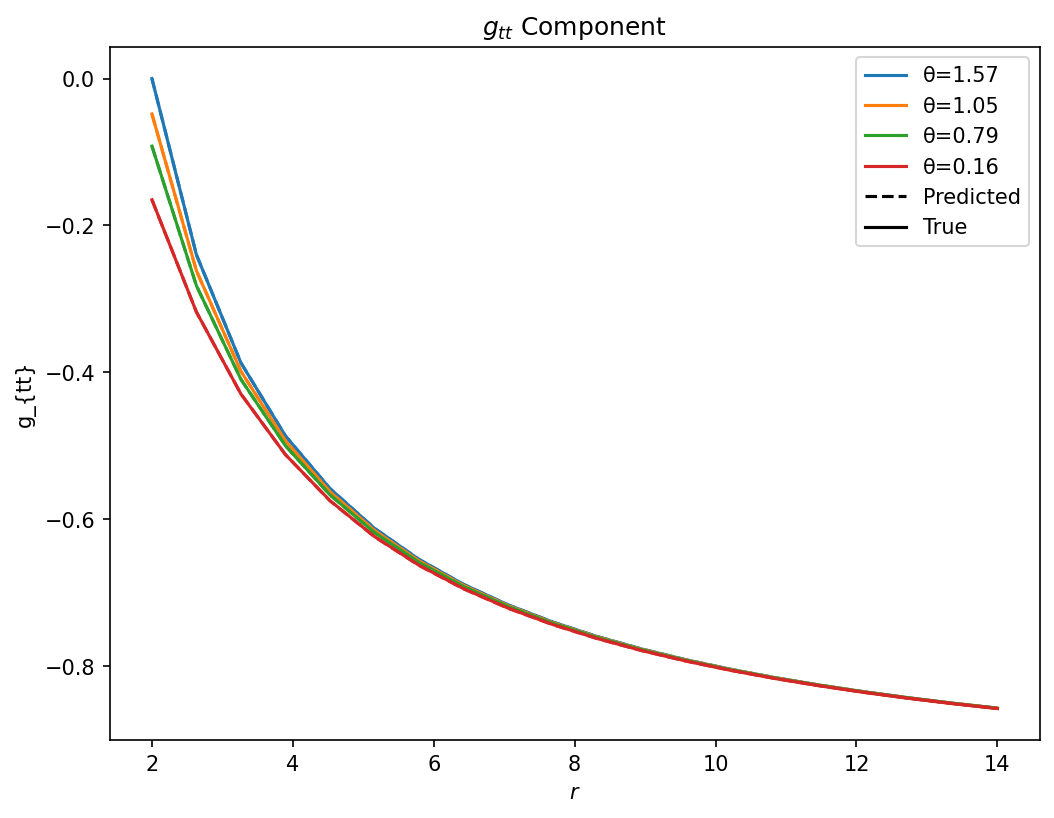

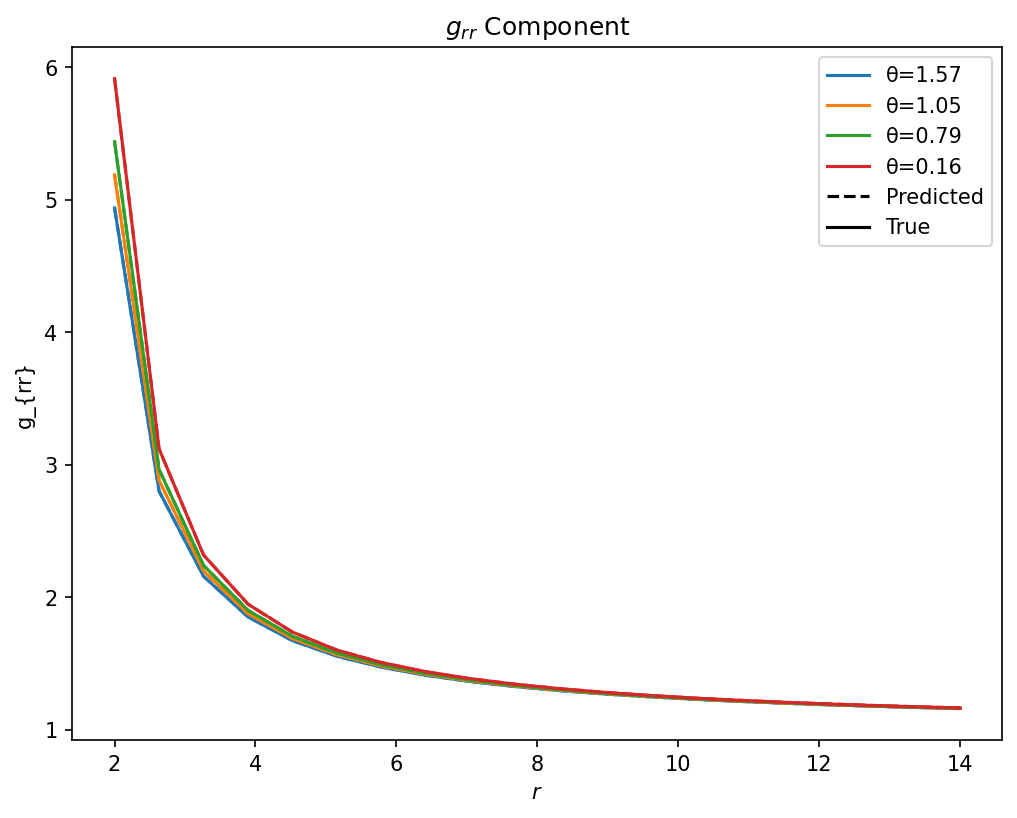

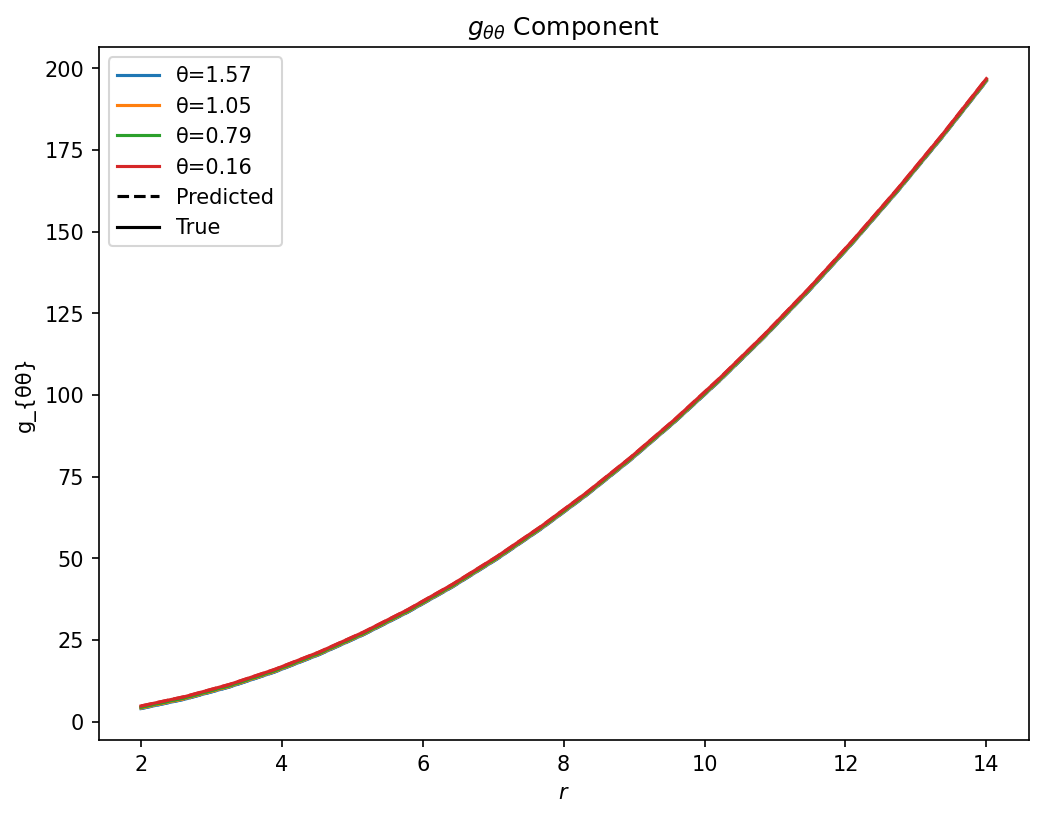

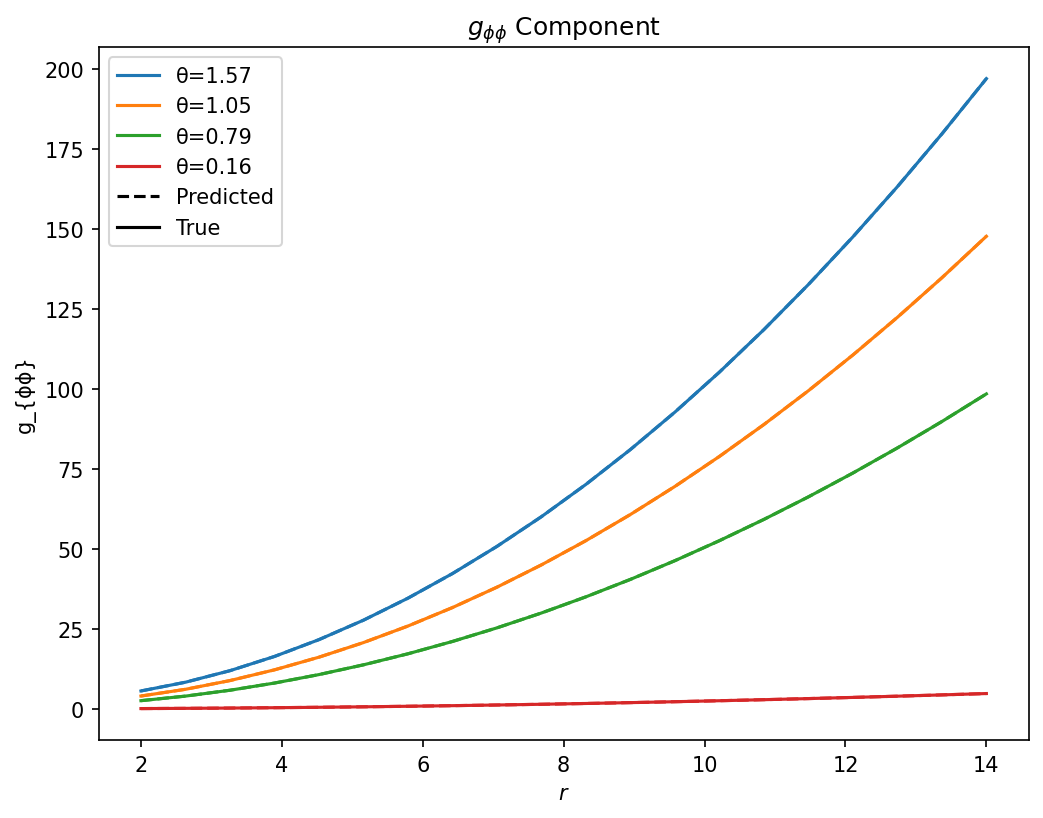

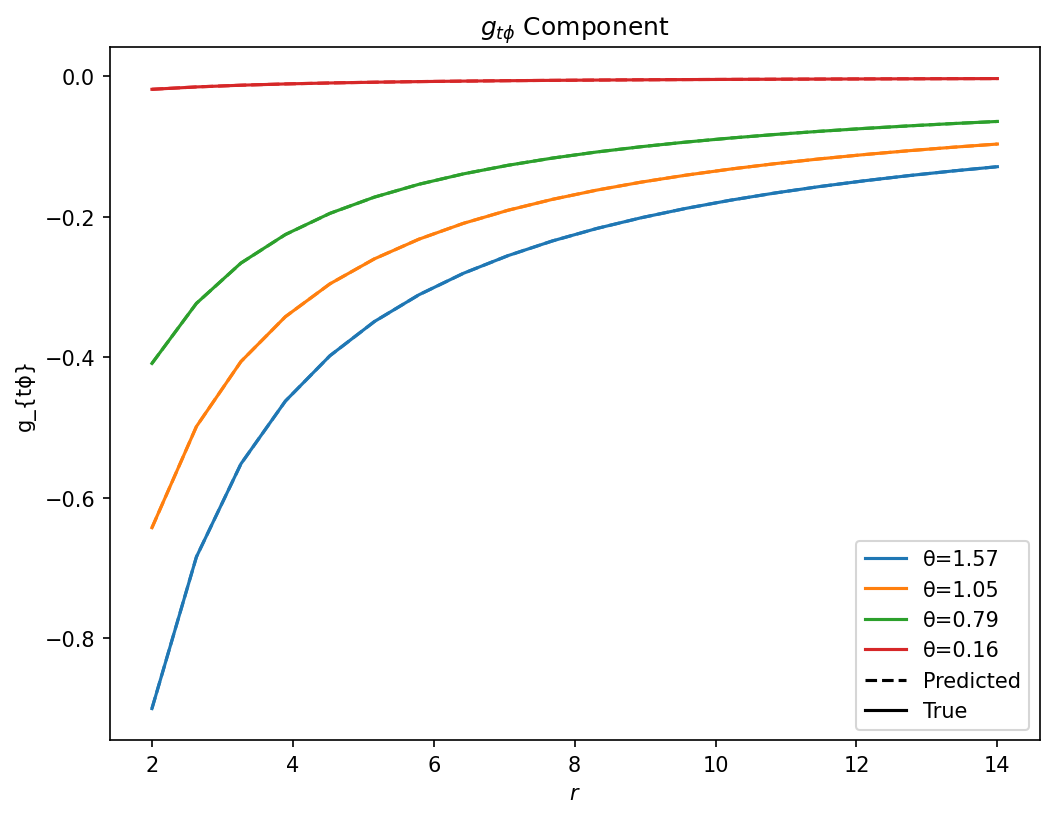

In [ ]:
fig, a, b = compare_metrics(net)

/tmp/ipykernel_194419/3873156370.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


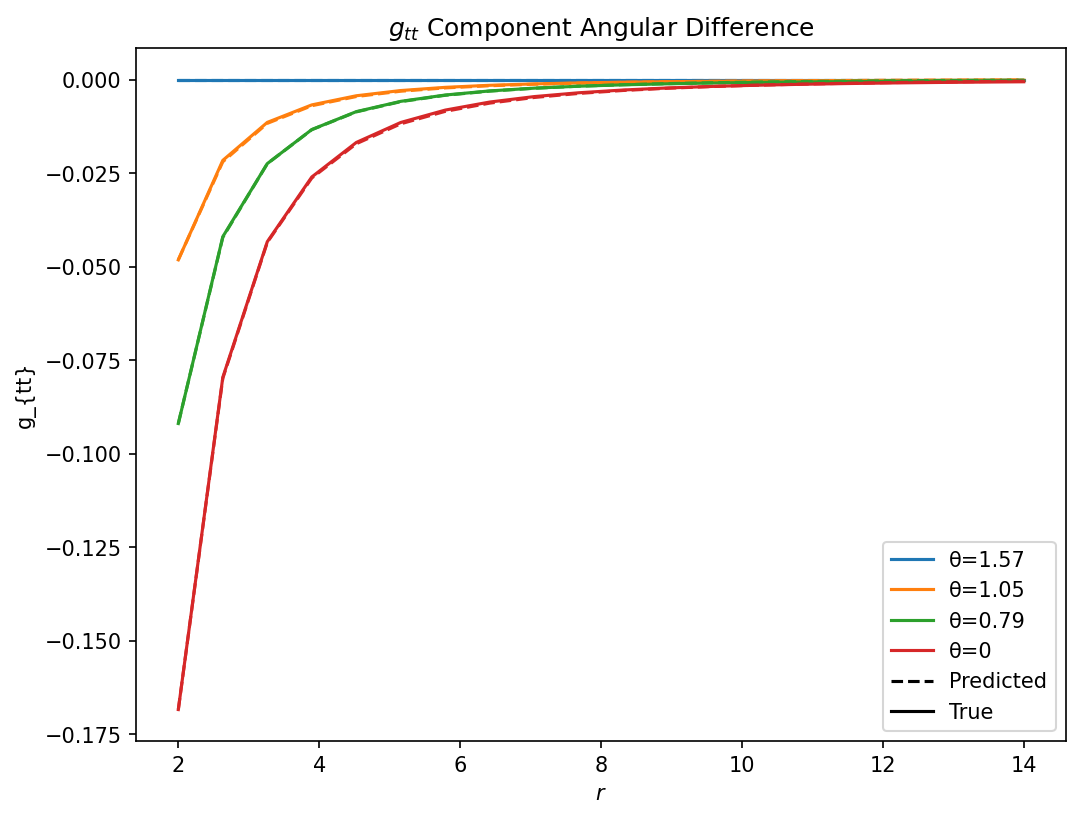

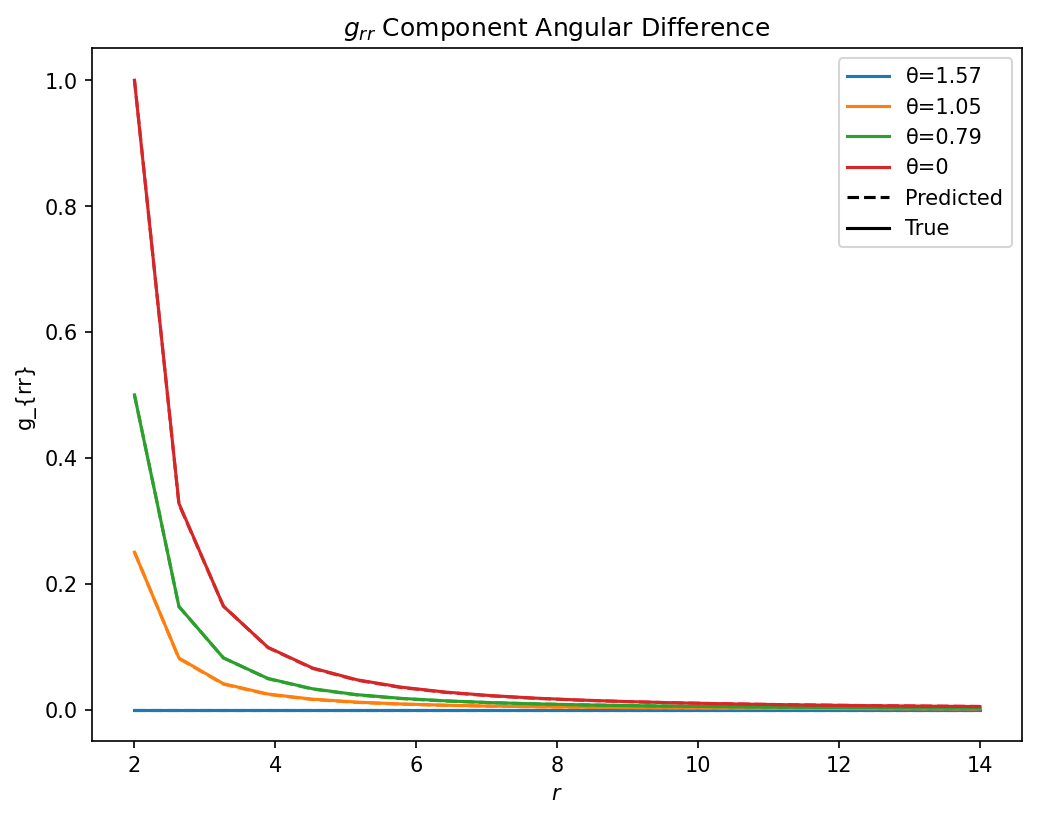

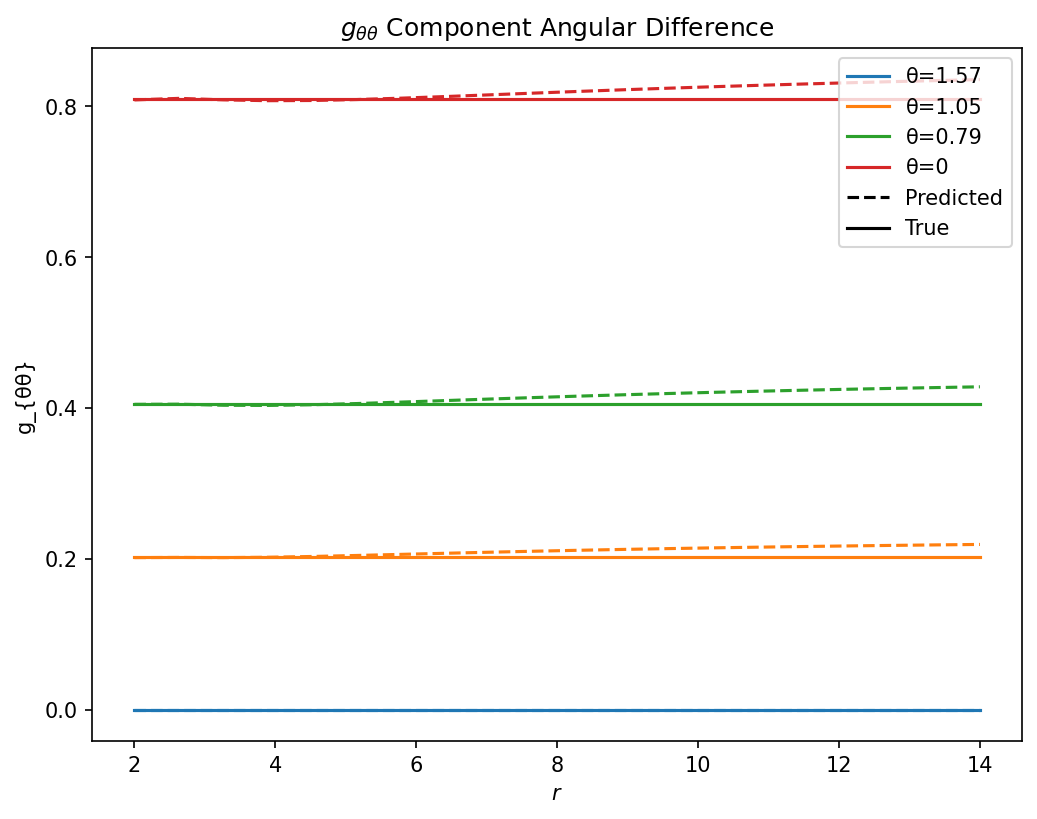

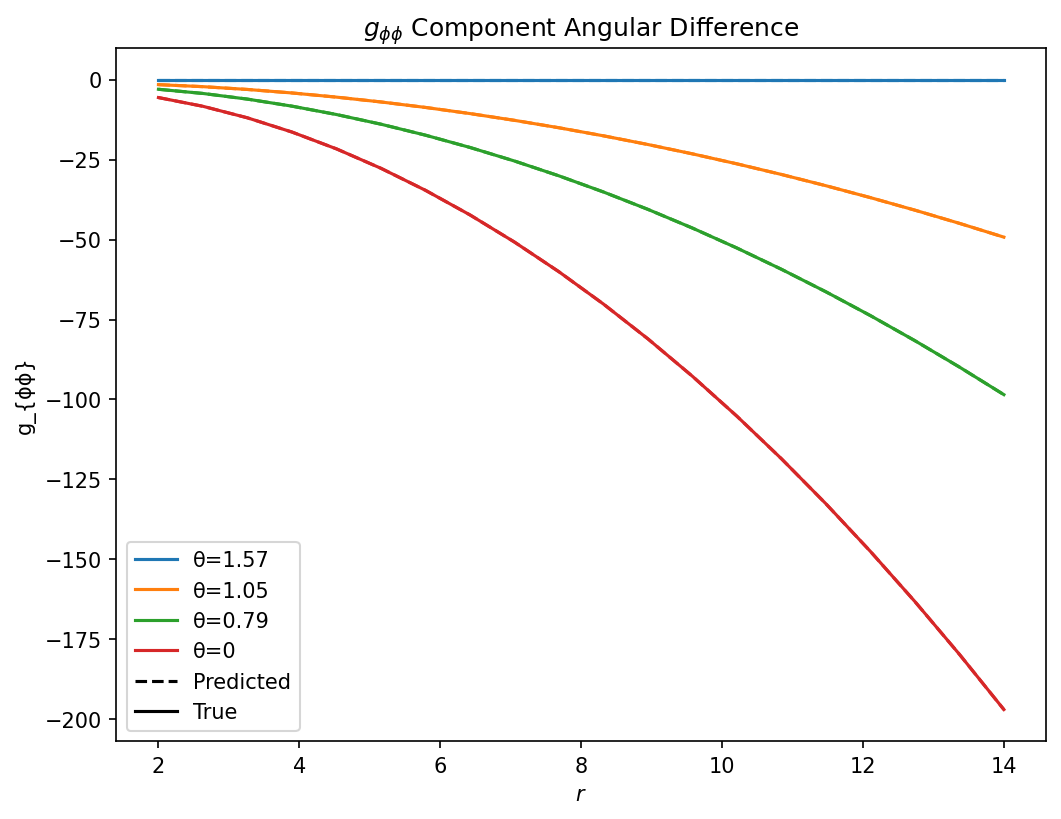

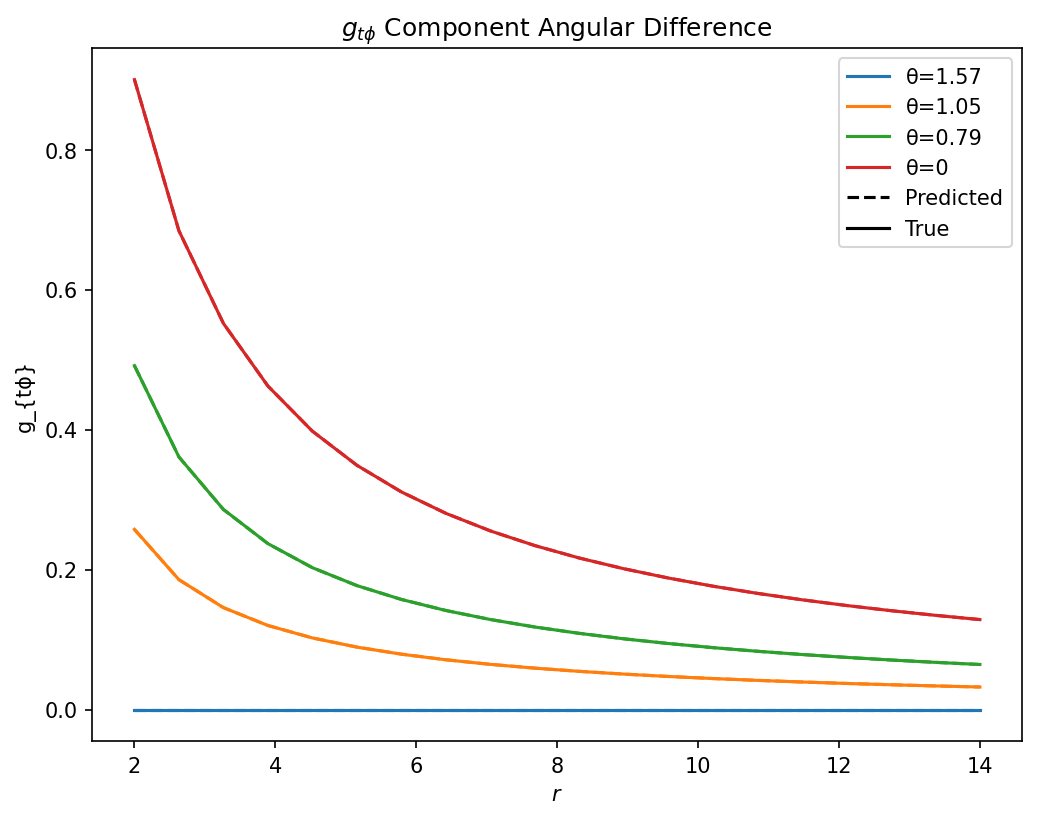

In [ ]:
def percent_diff(pred, true):
  return 100 * abs(pred - true) / abs(true)

b, c, d = angular_comparison_metrics(net)

In [ ]:
from prettytable import PrettyTable

def print_metric_error_table(network, r_grid = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20]):

    θ_grid = [π/20, π/4, π/3, π/2]

    components = {
        "g_tt": (0,0),
        "g_rr": (1,1),
        "g_θθ": (2,2),
        "g_ϕϕ": (3,3),
        "g_tϕ": (0,3),
    }

    errors = {name: [] for name in components}
    param = next(network.parameters())

    with torch.no_grad():
      for r in r_grid:
        pred_at_r = []
        true_at_r = []

        for θ in θ_grid:
          r_t = torch.tensor(r, dtype = param.dtype)
          θ_t = torch.tensor(θ, dtype = param.dtype)

          pred_at_r.append(metric_from_network(network, r_t, θ_t))
          true_at_r.append(g_Kerr(r_t, θ_t))

        pred_at_r = torch.stack(pred_at_r)
        true_at_r = torch.stack(true_at_r)

        for name, (μ, ν) in components.items():
          error = rel_L2_error(
              pred_at_r[:, μ, ν],
              true_at_r[:, μ, ν]
          )

          errors[name].append(error.item())

    table = PrettyTable()
    table.title = "Metric Relative L2 Error Across θ (%)"
    table.field_names = [
        "Component",
        *[f"r={r:g}" for r in r_grid]
    ]
    table.float_format = ".2"

    for name in components:
      table.add_row([name, *errors[name]])

    print(table)
    return table, errors

In [ ]:
metric_table, metric_errors = print_metric_error_table(net)

+-----------------------------------------------------------------------------------------------+
|                             Metric Relative L2 Error Across θ (%)                             |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
| Component | r=2  | r=3  | r=4  | r=5  | r=6  | r=7  | r=8  | r=10 | r=12 | r=14 | r=16 | r=20 |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
|    g_tt   | 0.01 | 0.04 | 0.02 | 0.03 | 0.02 | 0.02 | 0.01 | 0.00 | 0.01 | 0.01 | 0.01 | 0.02 |
|    g_rr   | 0.01 | 0.02 | 0.01 | 0.02 | 0.02 | 0.01 | 0.01 | 0.00 | 0.01 | 0.01 | 0.01 | 0.01 |
|    g_θθ   | 0.01 | 0.00 | 0.01 | 0.00 | 0.00 | 0.01 | 0.01 | 0.01 | 0.01 | 0.01 | 0.00 | 0.00 |
|    g_ϕϕ   | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
|    g_tϕ   | 0.02 | 0.02 | 0.02 | 0.01 | 0.01 | 0.01 | 0.01 | 0.01 | 0.01 | 0.01 | 0.01 | 0.02 |
+-----------+------+

# Save Results

In [ ]:
torch.save(
    net.state_dict(),
    "/content/sonar_v10_0.pt"
)